In [1]:

import sqlite3

conn = sqlite3.connect('emobility copy.db')

In [2]:
import pandas as pd

tables = pd.read_sql_query("SELECT name FROM sqlite_master WHERE type='table';", conn)

In [3]:
tables

,name
0,e_mobility_data_template_sow_4.1
1,kenya_ev_stations_(1)
2,e_mobility_data_template_sow_4_1
3,for_publication_africa_ev_readiness_impact_ind...
4,unep_eac_emobility_gantt_chart
5,unep_eac_emobility_weekly_live_chart
6,battery_eol
7,country_qualitative
8,eac_countries
9,financing


In [4]:
bat = pd.read_sql("""SELECT * FROM battery_eol""", conn)
bat.head()

,country_iso,year,battery_chemistry,volume_units,collection_rate_pct,recycling_facility_count,regulatory_status,data_source,notes
0,KE,2024,LFP,5000,10,1,draft,EPRA,No formal EPR
1,KE,2024,lead_acid,15000,45,3,enacted,NEMA,Legacy ICE batteries
2,RW,2024,LFP,3000,15,1,draft,REMA,NaN
3,RW,2024,lead_acid,8000,40,2,enacted,REMA,Legacy ICE batteries
4,UG,2024,lead_acid,12000,35,2,absent,NEMA,Legacy ICE batteries


In [5]:
bat.columns

Index(['country_iso', 'year', 'battery_chemistry', 'volume_units',
       'collection_rate_pct', 'recycling_facility_count', 'regulatory_status',
       'data_source', 'notes'],
      dtype='str')

In [6]:
country_q = pd.read_sql("""SELECT * FROM country_qualitative""", conn)
country_q.head()

,country_iso,country_name,ev_market_stage,primary_segment,charging_infrastructure,data_availability,key_barrier,key_opportunity,notes
0,TZ,Tanzania,Early growth,2W and 3W,Sparse but expanding,Low,Registration enforcement gap,Urban 2W electrification,10k+ estimate; EWURA guidelines 2026
1,BI,Burundi,Nascent,All,Minimal,NaN,No grid access,Policy framework in place,ICE import ban planned 2027
2,SS,South Sudan,Nascent,All,NaN,NaN,No grid access,Hybrid bridge,Hybrids preferred; no EV policy
3,CD,DR Congo,Nascent,All,Minimal,NaN,No grid access,Hydro-powered charging,No EV policy; SNEL grid mostly hydro
4,SO,Somalia,Nascent,All,NaN,NaN,No grid access,Private sector imports,Small-scale importers; no government policy


In [7]:
country_q.columns

Index(['country_iso', 'country_name', 'ev_market_stage', 'primary_segment',
       'charging_infrastructure', 'data_availability', 'key_barrier',
       'key_opportunity', 'notes'],
      dtype='str')

In [8]:
eac = pd.read_sql("""SELECT * FROM eac_countries""", conn)
eac.head()

,country_iso,country_name,eac_partner_state,accession_year,population,gdp_usd,currency_code,notes
0,KE,Kenya,1,2000,55100586,113400000000,KES,Founding member
1,RW,Rwanda,1,2007,14100000,14100000000,RWF,NaN
2,UG,Uganda,1,2000,48600000,49200000000,UGX,Founding member
3,TZ,Tanzania,1,2000,67400000,79100000000,TZS,Founding member
4,BI,Burundi,1,2007,13200000,3000000000,BIF,NaN


In [9]:
eac.columns

Index(['country_iso', 'country_name', 'eac_partner_state', 'accession_year',
       'population', 'gdp_usd', 'currency_code', 'notes'],
      dtype='str')

In [10]:
fis = pd.read_sql("""SELECT * FROM fiscal_tariffs""", conn)
fis.head()

,country_iso,year,vehicle_segment,duty_rate_ice,duty_rate_ev,vat_rate_ice,vat_rate_ev,data_source,notes
0,KE,2024,all,25.0,10.0,16.0,0.0,Kenya Gazette,NaN
1,RW,2024,all,25.0,0.0,18.0,0.0,RRA,NaN
2,UG,2024,all,25.0,0.0,18.0,0.0,URA,NaN
3,TZ,2024,all,25.0,10.0,18.0,0.0,TRA,NaN
4,BI,2024,all,NaN,NaN,NaN,NaN,OBR,VAT and customs exempt


In [11]:
fis.columns

Index(['country_iso', 'year', 'vehicle_segment', 'duty_rate_ice',
       'duty_rate_ev', 'vat_rate_ice', 'vat_rate_ev', 'data_source', 'notes'],
      dtype='str')

In [12]:
ind = pd.read_sql("""SELECT * FROM industrial_value_chain""", conn)
ind.head()

,country_iso,year,value_chain_stage,company_name,capacity_units_year,employment_count,year_established,local_content_pct,data_source,notes
0,KE,2024,assembly,ROAM Motors,5000.0,250.0,2017.0,15.0,ROAM,NaN
1,KE,2024,assembly,Arc Ride,3000.0,150.0,2020.0,12.0,Arc Ride,NaN
2,KE,2024,battery,Powerhive,2000.0,120.0,2015.0,10.0,Powerhive,NaN
3,RW,2024,assembly,Ampersand,10000.0,400.0,2016.0,20.0,Ampersand,NaN
4,RW,2024,assembly,Volt Rwanda,2000.0,100.0,2019.0,15.0,Volt Rwanda,NaN


In [13]:
ind.columns

Index(['country_iso', 'year', 'value_chain_stage', 'company_name',
       'capacity_units_year', 'employment_count', 'year_established',
       'local_content_pct', 'data_source', 'notes'],
      dtype='str')

In [14]:
mar = pd.read_sql("""SELECT * FROM market_fleet""", conn)
mar.head()

,country_iso,year,vehicle_segment,propulsion_type,new_registrations,cumulative_stock,data_source,data_confidence,notes
0,KE,2020,all,BEV,NaN,300.0,EPRA,high,Baseline
1,KE,2021,all,BEV,NaN,584.0,EPRA,high,NaN
2,KE,2022,all,BEV,NaN,1059.0,EPRA,high,NaN
3,KE,2023,all,BEV,NaN,3753.0,EPRA,high,NaN
4,KE,2024,all,BEV,NaN,5294.0,EPRA,high,NaN


In [15]:
mar.columns

Index(['country_iso', 'year', 'vehicle_segment', 'propulsion_type',
       'new_registrations', 'cumulative_stock', 'data_source',
       'data_confidence', 'notes'],
      dtype='str')

In [16]:
pol = pd.read_sql("""SELECT * FROM policy_inventory""", conn)
pol.head()

,country_iso,year,enacted_policy_instrument,instrument_type,category,status,effective_date,vehicle_segment,description,data_source
0,KE,2023,Finance Act 2023 EV VAT Exemption,fiscal,VAT,enacted,2023-07-01,all,Exempts EVs from 16% VAT,Kenya Gazette
1,KE,2023,Finance Act 2023 EV Duty Reduction,fiscal,import_duty,enacted,2023-07-01,all,Reduces EV import duty from 25% to 10%,Kenya Gazette
2,KE,2024,National E-Mobility Policy,regulatory,target,draft,2024-01-01,all,5% EV adoption by 2030,MoR&T
3,KE,2024,EPRA Charging Infrastructure Guidelines,regulatory,standard,enacted,2024-03-01,all,Technical standards for charging stations,EPRA
4,RW,2024,Rwanda EV Incentive Framework,fiscal,VAT,enacted,2024-01-01,all,EVs exempt from VAT and import duty,RRA


In [17]:
pol.columns

Index(['country_iso', 'year', 'enacted_policy_instrument', 'instrument_type',
       'category', 'status', 'effective_date', 'vehicle_segment',
       'description', 'data_source'],
      dtype='str')

In [18]:
print(pol.shape)
print(pol.columns.tolist())
print(pol.head())

(22, 10)
['country_iso', 'year', 'enacted_policy_instrument', 'instrument_type', 'category', 'status', 'effective_date', 'vehicle_segment', 'description', 'data_source']
  country_iso  year                enacted_policy_instrument instrument_type  \
0          KE  2023        Finance Act 2023 EV VAT Exemption          fiscal   
1          KE  2023       Finance Act 2023 EV Duty Reduction          fiscal   
2          KE  2024               National E-Mobility Policy      regulatory   
3          KE  2024  EPRA Charging Infrastructure Guidelines      regulatory   
4          RW  2024            Rwanda EV Incentive Framework          fiscal   

      category   status effective_date vehicle_segment  \
0          VAT  enacted     2023-07-01             all   
1  import_duty  enacted     2023-07-01             all   
2       target    draft     2024-01-01             all   
3     standard  enacted     2024-03-01             all   
4          VAT  enacted     2024-01-01             all   



In [19]:
pol.info()

<class 'pandas.DataFrame'>
RangeIndex: 22 entries, 0 to 21
Data columns (total 10 columns):
 #   Column                     Non-Null Count  Dtype
---  ------                     --------------  -----
 0   country_iso                22 non-null     str  
 1   year                       22 non-null     str  
 2   enacted_policy_instrument  22 non-null     str  
 3   instrument_type            22 non-null     str  
 4   category                   22 non-null     str  
 5   status                     22 non-null     str  
 6   effective_date             22 non-null     str  
 7   vehicle_segment            22 non-null     str  
 8   description                22 non-null     str  
 9   data_source                22 non-null     str  
dtypes: str(10)
memory usage: 1.8 KB


In [20]:
pow = pd.read_sql("""SELECT * FROM power_systems""", conn)
pow.head()

,country_iso,year,installed_capacity_mw,generation_hydro_pct,generation_solar_pct,generation_wind_pct,generation_thermal_pct,generation_other_pct,national_access_rate,urban_access_rate,rural_access_rate,peak_demand_mw,reserve_margin_pct,grid_emission_factor,data_source
0,KE,2024,3100.5,35,25,15,20,5,76,95,55,2200,40,0.15,EPRA/KPLC
1,RW,2024,195.0,45,10,5,35,5,65,90,45,150,30,0.35,REG
2,UG,2024,1250.0,80,5,0,15,0,45,85,30,900,38,0.12,UETCL
3,TZ,2024,3000.0,40,5,2,50,3,40,80,25,2000,50,0.45,TANESCO
4,BI,2024,100.0,90,2,0,8,0,12,50,5,80,25,0.08,REGIDESO


In [21]:
pow.columns

Index(['country_iso', 'year', 'installed_capacity_mw', 'generation_hydro_pct',
       'generation_solar_pct', 'generation_wind_pct', 'generation_thermal_pct',
       'generation_other_pct', 'national_access_rate', 'urban_access_rate',
       'rural_access_rate', 'peak_demand_mw', 'reserve_margin_pct',
       'grid_emission_factor', 'data_source'],
      dtype='str')

## Data Cleaning


### Battery eol

In [22]:
bat

,country_iso,year,battery_chemistry,volume_units,collection_rate_pct,recycling_facility_count,regulatory_status,data_source,notes
0,KE,2024,LFP,5000,10,1,draft,EPRA,No formal EPR
1,KE,2024,lead_acid,15000,45,3,enacted,NEMA,Legacy ICE batteries
2,RW,2024,LFP,3000,15,1,draft,REMA,NaN
3,RW,2024,lead_acid,8000,40,2,enacted,REMA,Legacy ICE batteries
4,UG,2024,lead_acid,12000,35,2,absent,NEMA,Legacy ICE batteries


In [23]:
bat.shape

(5, 9)

In [24]:
bat.info()

<class 'pandas.DataFrame'>
RangeIndex: 5 entries, 0 to 4
Data columns (total 9 columns):
 #   Column                    Non-Null Count  Dtype
---  ------                    --------------  -----
 0   country_iso               5 non-null      str  
 1   year                      5 non-null      int64
 2   battery_chemistry         5 non-null      str  
 3   volume_units              5 non-null      int64
 4   collection_rate_pct       5 non-null      int64
 5   recycling_facility_count  5 non-null      int64
 6   regulatory_status         5 non-null      str  
 7   data_source               5 non-null      str  
 8   notes                     4 non-null      str  
dtypes: int64(4), str(5)
memory usage: 492.0 bytes


In [25]:
bat.describe()

,year,volume_units,collection_rate_pct,recycling_facility_count
count,5.0,5.000000,5.000000,5.00000
mean,2024.0,8600.000000,29.000000,1.80000
std,0.0,4929.503018,15.572412,0.83666
min,2024.0,3000.000000,10.000000,1.00000
25%,2024.0,5000.000000,15.000000,1.00000
50%,2024.0,8000.000000,35.000000,2.00000
75%,2024.0,12000.000000,40.000000,2.00000
max,2024.0,15000.000000,45.000000,3.00000


In [26]:
bat.isnull().sum()

country_iso                 0
year                        0
battery_chemistry           0
volume_units                0
collection_rate_pct         0
recycling_facility_count    0
regulatory_status           0
data_source                 0
notes                       1
dtype: int64

In [27]:
bat.fillna("unknown", inplace=True)


,country_iso,year,battery_chemistry,volume_units,collection_rate_pct,recycling_facility_count,regulatory_status,data_source,notes
0,KE,2024,LFP,5000,10,1,draft,EPRA,No formal EPR
1,KE,2024,lead_acid,15000,45,3,enacted,NEMA,Legacy ICE batteries
2,RW,2024,LFP,3000,15,1,draft,REMA,unknown
3,RW,2024,lead_acid,8000,40,2,enacted,REMA,Legacy ICE batteries
4,UG,2024,lead_acid,12000,35,2,absent,NEMA,Legacy ICE batteries


In [28]:
bat.isnull().sum()

country_iso                 0
year                        0
battery_chemistry           0
volume_units                0
collection_rate_pct         0
recycling_facility_count    0
regulatory_status           0
data_source                 0
notes                       0
dtype: int64

In [29]:
bat.to_csv("battery_eol_cleaned.csv", index=False)

## country_qualitative

In [30]:
country_q.shape

(5, 9)

In [31]:
country_q.info()

<class 'pandas.DataFrame'>
RangeIndex: 5 entries, 0 to 4
Data columns (total 9 columns):
 #   Column                   Non-Null Count  Dtype
---  ------                   --------------  -----
 0   country_iso              5 non-null      str  
 1   country_name             5 non-null      str  
 2   ev_market_stage          5 non-null      str  
 3   primary_segment          5 non-null      str  
 4   charging_infrastructure  3 non-null      str  
 5   data_availability        1 non-null      str  
 6   key_barrier              5 non-null      str  
 7   key_opportunity          5 non-null      str  
 8   notes                    5 non-null      str  
dtypes: str(9)
memory usage: 492.0 bytes


In [32]:
country_q.describe().T

,count,unique,top,freq
country_iso,5,5,TZ,1
country_name,5,5,Tanzania,1
ev_market_stage,5,2,Nascent,4
primary_segment,5,2,All,4
charging_infrastructure,3,2,Minimal,2
data_availability,1,1,Low,1
key_barrier,5,2,No grid access,4
key_opportunity,5,5,Urban 2W electrification,1
notes,5,5,10k+ estimate; EWURA guidelines 2026,1


In [33]:
country_q.isnull().sum()

country_iso                0
country_name               0
ev_market_stage            0
primary_segment            0
charging_infrastructure    2
data_availability          4
key_barrier                0
key_opportunity            0
notes                      0
dtype: int64

In [34]:
country_q = country_q.fillna({
    'charging_infrastructure': 'abscent',
    'data_availability': 'not available'
})


In [35]:
country_q.isnull().sum()

country_iso                0
country_name               0
ev_market_stage            0
primary_segment            0
charging_infrastructure    0
data_availability          0
key_barrier                0
key_opportunity            0
notes                      0
dtype: int64

In [36]:
country_q.to_csv("country_qualitative_cleaned.csv", index=False)

## eac countries

In [37]:
eac.shape

(8, 8)

In [38]:
eac.info()

<class 'pandas.DataFrame'>
RangeIndex: 8 entries, 0 to 7
Data columns (total 8 columns):
 #   Column             Non-Null Count  Dtype
---  ------             --------------  -----
 0   country_iso        8 non-null      str  
 1   country_name       8 non-null      str  
 2   eac_partner_state  8 non-null      int64
 3   accession_year     8 non-null      int64
 4   population         8 non-null      int64
 5   gdp_usd            8 non-null      int64
 6   currency_code      8 non-null      str  
 7   notes              5 non-null      str  
dtypes: int64(4), str(4)
memory usage: 644.0 bytes


In [39]:
eac.describe()

,eac_partner_state,accession_year,population,gdp_usd
count,8.0,8.000000,8.000000e+00,8.000000e+00
mean,1.0,2009.500000,4.123007e+07,4.286250e+10
std,0.0,9.942693,3.301481e+07,4.084748e+10
min,1.0,2000.000000,1.100000e+07,3.000000e+09
25%,1.0,2000.000000,1.387500e+07,9.650000e+09
50%,1.0,2007.000000,3.337000e+07,3.165000e+10
75%,1.0,2017.500000,5.817544e+07,6.995000e+10
max,1.0,2024.000000,1.023000e+08,1.134000e+11


In [40]:
eac.isnull().sum()

country_iso          0
country_name         0
eac_partner_state    0
accession_year       0
population           0
gdp_usd              0
currency_code        0
notes                3
dtype: int64

In [41]:
eac["notes"].unique()

<StringArray>
['Founding member', nan, 'Joined 2022', 'Joined 2024']
Length: 4, dtype: str

In [42]:
eac=eac.fillna({
    'notes': 'Member'
    })

In [43]:
eac['notes'].unique()

<StringArray>
['Founding member', 'Member', 'Joined 2022', 'Joined 2024']
Length: 4, dtype: str

In [44]:
eac.to_csv("eac_countries_cleaned.csv", index=False)

## fiscal_tariffs

In [45]:
fis.shape

(8, 9)

In [46]:
fis.info()

<class 'pandas.DataFrame'>
RangeIndex: 8 entries, 0 to 7
Data columns (total 9 columns):
 #   Column           Non-Null Count  Dtype  
---  ------           --------------  -----  
 0   country_iso      8 non-null      str    
 1   year             8 non-null      int64  
 2   vehicle_segment  8 non-null      str    
 3   duty_rate_ice    4 non-null      float64
 4   duty_rate_ev     4 non-null      float64
 5   vat_rate_ice     4 non-null      float64
 6   vat_rate_ev      4 non-null      float64
 7   data_source      8 non-null      str    
 8   notes            4 non-null      str    
dtypes: float64(4), int64(1), str(4)
memory usage: 708.0 bytes


In [47]:
fis.describe()

,year,duty_rate_ice,duty_rate_ev,vat_rate_ice,vat_rate_ev
count,8.0,4.0,4.000000,4.0,4.0
mean,2024.0,25.0,5.000000,17.5,0.0
std,0.0,0.0,5.773503,1.0,0.0
min,2024.0,25.0,0.000000,16.0,0.0
25%,2024.0,25.0,0.000000,17.5,0.0
50%,2024.0,25.0,5.000000,18.0,0.0
75%,2024.0,25.0,10.000000,18.0,0.0
max,2024.0,25.0,10.000000,18.0,0.0


In [48]:
fis.isnull().sum()

country_iso        0
year               0
vehicle_segment    0
duty_rate_ice      4
duty_rate_ev       4
vat_rate_ice       4
vat_rate_ev        4
data_source        0
notes              4
dtype: int64

In [49]:
fis

,country_iso,year,vehicle_segment,duty_rate_ice,duty_rate_ev,vat_rate_ice,vat_rate_ev,data_source,notes
0,KE,2024,all,25.0,10.0,16.0,0.0,Kenya Gazette,NaN
1,RW,2024,all,25.0,0.0,18.0,0.0,RRA,NaN
2,UG,2024,all,25.0,0.0,18.0,0.0,URA,NaN
3,TZ,2024,all,25.0,10.0,18.0,0.0,TRA,NaN
4,BI,2024,all,NaN,NaN,NaN,NaN,OBR,VAT and customs exempt
5,SS,2024,all,NaN,NaN,NaN,NaN,Ministry of Transport,No EV-specific tariff
6,CD,2024,all,NaN,NaN,NaN,NaN,Ministry of Transport,No EV-specific tariff
7,SO,2024,all,NaN,NaN,NaN,NaN,Ministry of Transport,No EV-specific tariff


In [50]:
fis = fis.fillna({
    'duty_rate_ice': 'unknown',
    'duty_rate_ev': 'unknown',
    'vat_rate_ice': 'unknown',
    'vat_rate_ev': 'unknown',
    'notes': 'none'
},inplace=True)

In [51]:
fis.isnull().sum()

country_iso        0
year               0
vehicle_segment    0
duty_rate_ice      0
duty_rate_ev       0
vat_rate_ice       0
vat_rate_ev        0
data_source        0
notes              0
dtype: int64

In [52]:
fis.to_csv("fiscal_tariffs_cleaned.csv", index=False)

## industrial_value_chain

In [53]:
ind.shape

(11, 10)

In [54]:
ind.info()

<class 'pandas.DataFrame'>
RangeIndex: 11 entries, 0 to 10
Data columns (total 10 columns):
 #   Column               Non-Null Count  Dtype  
---  ------               --------------  -----  
 0   country_iso          11 non-null     str    
 1   year                 11 non-null     int64  
 2   value_chain_stage    11 non-null     str    
 3   company_name         10 non-null     str    
 4   capacity_units_year  8 non-null      float64
 5   employment_count     8 non-null      float64
 6   year_established     8 non-null      float64
 7   local_content_pct    8 non-null      float64
 8   data_source          11 non-null     str    
 9   notes                2 non-null      str    
dtypes: float64(4), int64(1), str(5)
memory usage: 1012.0 bytes


In [55]:
ind.describe()

,year,capacity_units_year,employment_count,year_established,local_content_pct
count,11.000000,8.000000,8.000000,8.000000,8.000000
mean,2024.545455,4437.500000,196.250000,2017.500000,14.625000
std,0.934199,3245.188746,115.750656,2.976095,7.633339
min,2024.000000,500.000000,50.000000,2014.000000,0.000000
25%,2024.000000,2000.000000,115.000000,2015.750000,11.500000
50%,2024.000000,4000.000000,175.000000,2016.500000,15.000000
75%,2025.000000,5750.000000,262.500000,2019.250000,20.000000
max,2026.000000,10000.000000,400.000000,2023.000000,25.000000


In [56]:
ind.isnull().sum()

country_iso            0
year                   0
value_chain_stage      0
company_name           1
capacity_units_year    3
employment_count       3
year_established       3
local_content_pct      3
data_source            0
notes                  9
dtype: int64

In [57]:
ind

,country_iso,year,value_chain_stage,company_name,capacity_units_year,employment_count,year_established,local_content_pct,data_source,notes
0,KE,2024,assembly,ROAM Motors,5000.0,250.0,2017.0,15.0,ROAM,NaN
1,KE,2024,assembly,Arc Ride,3000.0,150.0,2020.0,12.0,Arc Ride,NaN
2,KE,2024,battery,Powerhive,2000.0,120.0,2015.0,10.0,Powerhive,NaN
3,RW,2024,assembly,Ampersand,10000.0,400.0,2016.0,20.0,Ampersand,NaN
4,RW,2024,assembly,Volt Rwanda,2000.0,100.0,2019.0,15.0,Volt Rwanda,NaN
5,UG,2024,assembly,Zembo,8000.0,300.0,2016.0,25.0,Zembo,NaN
6,UG,2024,assembly,Bodawerk,5000.0,200.0,2014.0,20.0,Bodawerk,NaN
7,UG,2024,recycling,NaN,500.0,50.0,2023.0,0.0,AfEMA,NaN
8,TZ,2026,assembly,Spiro,NaN,NaN,NaN,NaN,Daily News,NaN
9,TZ,2026,assembly,TankVolt,NaN,NaN,NaN,NaN,Daily News,Chinese subsidiary of Transsion Holdings


In [58]:
ind = ind.fillna({
    'capacity_units_year': '0',
    'employment_count':'0',
    'company_name':'unknown',
    'year_established':'0.0',
    'data_source':'unknown'
    
})

In [59]:
ind['year'] = ind['year'].astype(int).astype(str)
ind['year'] = pd.to_datetime(ind['year'], format='%Y')

In [60]:
ind.info()

<class 'pandas.DataFrame'>
RangeIndex: 11 entries, 0 to 10
Data columns (total 10 columns):
 #   Column               Non-Null Count  Dtype         
---  ------               --------------  -----         
 0   country_iso          11 non-null     str           
 1   year                 11 non-null     datetime64[us]
 2   value_chain_stage    11 non-null     str           
 3   company_name         11 non-null     str           
 4   capacity_units_year  11 non-null     object        
 5   employment_count     11 non-null     object        
 6   year_established     11 non-null     object        
 7   local_content_pct    8 non-null      float64       
 8   data_source          11 non-null     str           
 9   notes                2 non-null      str           
dtypes: datetime64[us](1), float64(1), object(3), str(5)
memory usage: 1012.0+ bytes


In [61]:
ind

,country_iso,year,value_chain_stage,company_name,capacity_units_year,employment_count,year_established,local_content_pct,data_source,notes
0,KE,2024-01-01,assembly,ROAM Motors,5000.0,250.0,2017.0,15.0,ROAM,NaN
1,KE,2024-01-01,assembly,Arc Ride,3000.0,150.0,2020.0,12.0,Arc Ride,NaN
2,KE,2024-01-01,battery,Powerhive,2000.0,120.0,2015.0,10.0,Powerhive,NaN
3,RW,2024-01-01,assembly,Ampersand,10000.0,400.0,2016.0,20.0,Ampersand,NaN
4,RW,2024-01-01,assembly,Volt Rwanda,2000.0,100.0,2019.0,15.0,Volt Rwanda,NaN
5,UG,2024-01-01,assembly,Zembo,8000.0,300.0,2016.0,25.0,Zembo,NaN
6,UG,2024-01-01,assembly,Bodawerk,5000.0,200.0,2014.0,20.0,Bodawerk,NaN
7,UG,2024-01-01,recycling,unknown,500.0,50.0,2023.0,0.0,AfEMA,NaN
8,TZ,2026-01-01,assembly,Spiro,0,0,0.0,NaN,Daily News,NaN
9,TZ,2026-01-01,assembly,TankVolt,0,0,0.0,NaN,Daily News,Chinese subsidiary of Transsion Holdings


In [62]:
ind.fillna({
    'notes': 'none',
    'local_content_pct': '0.0'
}, inplace=True)

,country_iso,year,value_chain_stage,company_name,capacity_units_year,employment_count,year_established,local_content_pct,data_source,notes
0,KE,2024-01-01,assembly,ROAM Motors,5000.0,250.0,2017.0,15.0,ROAM,none
1,KE,2024-01-01,assembly,Arc Ride,3000.0,150.0,2020.0,12.0,Arc Ride,none
2,KE,2024-01-01,battery,Powerhive,2000.0,120.0,2015.0,10.0,Powerhive,none
3,RW,2024-01-01,assembly,Ampersand,10000.0,400.0,2016.0,20.0,Ampersand,none
4,RW,2024-01-01,assembly,Volt Rwanda,2000.0,100.0,2019.0,15.0,Volt Rwanda,none
5,UG,2024-01-01,assembly,Zembo,8000.0,300.0,2016.0,25.0,Zembo,none
6,UG,2024-01-01,assembly,Bodawerk,5000.0,200.0,2014.0,20.0,Bodawerk,none
7,UG,2024-01-01,recycling,unknown,500.0,50.0,2023.0,0.0,AfEMA,none
8,TZ,2026-01-01,assembly,Spiro,0,0,0.0,0.0,Daily News,none
9,TZ,2026-01-01,assembly,TankVolt,0,0,0.0,0.0,Daily News,Chinese subsidiary of Transsion Holdings


In [63]:
ind.isnull().sum()

country_iso            0
year                   0
value_chain_stage      0
company_name           0
capacity_units_year    0
employment_count       0
year_established       0
local_content_pct      0
data_source            0
notes                  0
dtype: int64

In [64]:
ind.to_csv("industrial_value_chain_cleaned.csv", index=False)

## Market Fleet

In [65]:
mar.shape

(20, 9)

In [66]:
mar.info()

<class 'pandas.DataFrame'>
RangeIndex: 20 entries, 0 to 19
Data columns (total 9 columns):
 #   Column             Non-Null Count  Dtype  
---  ------             --------------  -----  
 0   country_iso        20 non-null     str    
 1   year               20 non-null     int64  
 2   vehicle_segment    20 non-null     str    
 3   propulsion_type    20 non-null     str    
 4   new_registrations  7 non-null      float64
 5   cumulative_stock   19 non-null     float64
 6   data_source        20 non-null     str    
 7   data_confidence    20 non-null     str    
 8   notes              6 non-null      str    
dtypes: float64(2), int64(1), str(6)
memory usage: 1.5 KB


In [67]:
mar.describe()

,year,new_registrations,cumulative_stock
count,20.000000,7.000000,19.000000
mean,2022.750000,762.428571,2330.473684
std,1.831738,1560.879117,2916.874323
min,2020.000000,19.000000,19.000000
25%,2021.000000,23.500000,118.500000
50%,2023.000000,96.000000,584.000000
75%,2024.250000,450.500000,3576.500000
max,2025.000000,4274.000000,10000.000000


In [68]:
mar.isnull().sum()

country_iso           0
year                  0
vehicle_segment       0
propulsion_type       0
new_registrations    13
cumulative_stock      1
data_source           0
data_confidence       0
notes                14
dtype: int64

In [69]:
mar

,country_iso,year,vehicle_segment,propulsion_type,new_registrations,cumulative_stock,data_source,data_confidence,notes
0,KE,2020,all,BEV,NaN,300.0,EPRA,high,Baseline
1,KE,2021,all,BEV,NaN,584.0,EPRA,high,NaN
2,KE,2022,all,BEV,NaN,1059.0,EPRA,high,NaN
3,KE,2023,all,BEV,NaN,3753.0,EPRA,high,NaN
4,KE,2024,all,BEV,NaN,5294.0,EPRA,high,NaN
5,KE,2025,all,BEV,NaN,6442.0,EPRA,high,As of June 2025
6,RW,2020,passenger,BEV,19.0,19.0,RRA,high,NaN
7,RW,2021,passenger,BEV,19.0,38.0,RRA,high,NaN
8,RW,2021,passenger,HEV,28.0,28.0,RRA,high,NaN
9,RW,2022,passenger,BEV,96.0,134.0,RRA,high,NaN


In [70]:
mar.fillna({
    'new_registrations': 0,
    'cumulative_stock': 0,
    'notes': 'none'

},inplace=True)

,country_iso,year,vehicle_segment,propulsion_type,new_registrations,cumulative_stock,data_source,data_confidence,notes
0,KE,2020,all,BEV,0.0,300.0,EPRA,high,Baseline
1,KE,2021,all,BEV,0.0,584.0,EPRA,high,none
2,KE,2022,all,BEV,0.0,1059.0,EPRA,high,none
3,KE,2023,all,BEV,0.0,3753.0,EPRA,high,none
4,KE,2024,all,BEV,0.0,5294.0,EPRA,high,none
5,KE,2025,all,BEV,0.0,6442.0,EPRA,high,As of June 2025
6,RW,2020,passenger,BEV,19.0,19.0,RRA,high,none
7,RW,2021,passenger,BEV,19.0,38.0,RRA,high,none
8,RW,2021,passenger,HEV,28.0,28.0,RRA,high,none
9,RW,2022,passenger,BEV,96.0,134.0,RRA,high,none


In [71]:
mar.isnull().sum()

country_iso          0
year                 0
vehicle_segment      0
propulsion_type      0
new_registrations    0
cumulative_stock     0
data_source          0
data_confidence      0
notes                0
dtype: int64

In [72]:
mar.to_csv("market_fleet_cleaned.csv", index=False)

## Policy Inventory

In [73]:
pol.shape

(22, 10)

In [74]:
pol.info()

<class 'pandas.DataFrame'>
RangeIndex: 22 entries, 0 to 21
Data columns (total 10 columns):
 #   Column                     Non-Null Count  Dtype
---  ------                     --------------  -----
 0   country_iso                22 non-null     str  
 1   year                       22 non-null     str  
 2   enacted_policy_instrument  22 non-null     str  
 3   instrument_type            22 non-null     str  
 4   category                   22 non-null     str  
 5   status                     22 non-null     str  
 6   effective_date             22 non-null     str  
 7   vehicle_segment            22 non-null     str  
 8   description                22 non-null     str  
 9   data_source                22 non-null     str  
dtypes: str(10)
memory usage: 1.8 KB


In [75]:
pol.describe()

,country_iso,year,enacted_policy_instrument,instrument_type,category,status,effective_date,vehicle_segment,description,data_source
count,22,22,22,22,22,22,22,22,22,22
unique,8,5,19,2,8,6,10,2,20,16
top,KE,2024,No EV Policy,regulatory,target,enacted,,all,No dedicated EV policy framework,Ministry of Transport
freq,4,15,3,16,5,14,5,19,3,4


In [76]:
pol.isnull().sum()

country_iso                  0
year                         0
enacted_policy_instrument    0
instrument_type              0
category                     0
status                       0
effective_date               0
vehicle_segment              0
description                  0
data_source                  0
dtype: int64

In [77]:
pow.shape

(8, 15)

In [78]:
pow.info()

<class 'pandas.DataFrame'>
RangeIndex: 8 entries, 0 to 7
Data columns (total 15 columns):
 #   Column                  Non-Null Count  Dtype  
---  ------                  --------------  -----  
 0   country_iso             8 non-null      str    
 1   year                    8 non-null      int64  
 2   installed_capacity_mw   8 non-null      float64
 3   generation_hydro_pct    8 non-null      int64  
 4   generation_solar_pct    8 non-null      int64  
 5   generation_wind_pct     8 non-null      int64  
 6   generation_thermal_pct  8 non-null      int64  
 7   generation_other_pct    8 non-null      int64  
 8   national_access_rate    8 non-null      int64  
 9   urban_access_rate       8 non-null      int64  
 10  rural_access_rate       8 non-null      int64  
 11  peak_demand_mw          8 non-null      int64  
 12  reserve_margin_pct      8 non-null      int64  
 13  grid_emission_factor    8 non-null      float64
 14  data_source             8 non-null      str    
dtypes: f

In [79]:
pol.to_csv("policy_inventory_cleaned.csv", index=False)

In [80]:
pow.describe()

,year,installed_capacity_mw,generation_hydro_pct,generation_solar_pct,generation_wind_pct,generation_thermal_pct,generation_other_pct,national_access_rate,urban_access_rate,rural_access_rate,peak_demand_mw,reserve_margin_pct,grid_emission_factor
count,8.0,8.000000,8.000000,8.000000,8.000000,8.000000,8.000000,8.00000,8.000000,8.000000,8.0000,8.000000,8.000000
mean,2024.0,1351.937500,48.125000,9.125000,3.375000,37.750000,1.625000,35.12500,66.250000,21.500000,918.7500,36.000000,0.331250
std,0.0,1416.668386,37.505952,7.918108,5.180665,32.796995,2.326094,25.60378,24.604007,20.549592,940.4017,13.763305,0.279154
min,2024.0,100.000000,0.000000,1.000000,0.000000,4.000000,0.000000,8.00000,30.000000,2.000000,80.0000,20.000000,0.050000
25%,2024.0,142.500000,26.250000,4.250000,0.000000,13.250000,0.000000,14.25000,47.500000,5.000000,115.0000,25.000000,0.110000
50%,2024.0,722.500000,42.500000,7.500000,1.000000,27.500000,0.000000,30.00000,70.000000,15.000000,525.0000,34.000000,0.250000
75%,2024.0,2925.000000,82.500000,11.250000,5.000000,57.500000,3.500000,50.00000,86.250000,33.750000,1850.0000,42.500000,0.512500
max,2024.0,3100.500000,95.000000,25.000000,15.000000,90.000000,5.000000,76.00000,95.000000,55.000000,2200.0000,60.000000,0.750000


In [81]:
pow.isnull().sum()

country_iso               0
year                      0
installed_capacity_mw     0
generation_hydro_pct      0
generation_solar_pct      0
generation_wind_pct       0
generation_thermal_pct    0
generation_other_pct      0
national_access_rate      0
urban_access_rate         0
rural_access_rate         0
peak_demand_mw            0
reserve_margin_pct        0
grid_emission_factor      0
data_source               0
dtype: int64

In [82]:
pow.to_csv("power_systems_cleaned.csv", index=False)

# Charging stations

In [83]:
tables = pd.read_sql_query("SELECT name FROM sqlite_master WHERE type='table';", conn)
tables

,name
0,e_mobility_data_template_sow_4.1
1,kenya_ev_stations_(1)
2,e_mobility_data_template_sow_4_1
3,for_publication_africa_ev_readiness_impact_ind...
4,unep_eac_emobility_gantt_chart
5,unep_eac_emobility_weekly_live_chart
6,battery_eol
7,country_qualitative
8,eac_countries
9,financing


In [84]:
kenya_charge = pd.read_sql("""SELECT * FROM kenya_ev_stations_1""", conn)
kenya_charge.head()

,station_name,provider,county_region,coordinates,charger_types,number_of_ports,pricing,payment_methods,car_model_supported,operating_hours,status,average_rating
0,Sarit Centre Hub A,EVChaja,Nairobi,"-1.2588, 36.8037",AC Type 2 (22kW),4,KSh 35/kWh,"M-Pesa, App","BYD Atto 3, Nissan Leaf, Tesla Model 3, Hyunda...",06:00 - 22:00,Operational,4.5
1,Two Rivers Mall Fast Charge,EVChaja,Nairobi,"-1.2131, 36.7925",DC CCS2 Fast (50kW),2,KSh 45/kWh,"M-Pesa, App, Card","BYD Atto 3, Nissan Leaf, Tesla Model 3, Hyunda...",24/7,Operational,4.7
2,Waterfront Mall Karen,Asaph Green Mobility,Nairobi,"-1.3411, 36.7166",AC Type 2 (22kW),2,KSh 40/kWh,"M-Pesa, App","BYD Atto 3, Nissan Leaf, Tesla Model 3, Hyunda...",07:00 - 21:00,Operational,4.2
3,Mega City Mall Kisumu,EVChaja,Kisumu,"-0.1062, 34.7705",AC Type 2 (22kW),2,KSh 35/kWh,"M-Pesa, App","BYD Atto 3, Nissan Leaf, Tesla Model 3, Hyunda...",08:00 - 20:00,Operational,4.0
4,City Mall Nyali,EVChaja,Mombasa,"-4.0194, 39.7289",AC Type 2 (22kW),2,KSh 35/kWh,"M-Pesa, App","BYD Atto 3, Nissan Leaf, Tesla Model 3, Hyunda...",08:00 - 22:00,Operational,4.3


In [85]:
kenya_charge.columns

Index(['station_name', 'provider', 'county_region', 'coordinates',
       'charger_types', 'number_of_ports', 'pricing', 'payment_methods',
       'car_model_supported', 'operating_hours', 'status', 'average_rating'],
      dtype='str')

In [86]:
kenya_charge_infrast= pd.read_sql("""SELECT * FROM kenya_ev_charging_infrastructure""", conn)
kenya_charge_infrast.head()

,station_name,provider,county,location,coordinates,charger_types,number_of_ports,pricing,payment_methods,car_models_supported,motorcycle_support,operating_hours,status,average_rating
0,Stima Plaza,Kenya Power,Nairobi,"Parklands, Nairobi","-1.2641, 36.8161","50kW DC Fast Charger, 22kW AC Charger",2,Free,RFID Card,"BYD e6, Hyundai Kona Electric, Nissan Leaf, Re...",0,24/7,Operational,4.5
1,Ruaraka Depot,Kenya Power,Nairobi,"Ruaraka, Nairobi","-1.2567, 36.8833","50kW DC Fast Charger, 22kW AC Charger",2,Free,RFID Card,"BYD e6, Hyundai Kona Electric, Nissan Leaf, Re...",0,24/7,Operational,4.3
2,Donholm Depot,Kenya Power,Nairobi,"Donholm, Nairobi","-1.2937, 36.9006","50kW DC Fast Charger, 22kW AC Charger",2,Free,RFID Card,"BYD e6, Hyundai Kona Electric, Nissan Leaf, Re...",0,24/7,Operational,4.2
3,Ragati Depot,Kenya Power,Nairobi,"Ragati - Upperhill, Nairobi","-1.29558, 36.81281","50kW DC Fast Charger, 22kW AC Charger",2,Free,RFID Card,"BYD e6, Hyundai Kona Electric, Nissan Leaf, Re...",0,24/7,Operational,4.1
4,TotalEnergies-Roam Hub Lusaka Road,TotalEnergies | Roam-electric,Nairobi,"Lusaka Road, Nairobi","-1.30124, 36.83284","22kW AC Charger, Battery Swap for motorcycles",2,KSh 20-50 per kWh (varies by time),"M-Pesa, Credit Card, Debit Card",Not available,1,24/7,Operational,4.3


In [87]:
kenya_charge_infrast.columns

Index(['station_name', 'provider', 'county', 'location', 'coordinates',
       'charger_types', 'number_of_ports', 'pricing', 'payment_methods',
       'car_models_supported', 'motorcycle_support', 'operating_hours',
       'status', 'average_rating'],
      dtype='str')

In [88]:
kenya_charge_infrast.drop(columns=['location', 'motorcycle_support'], inplace=True)



In [89]:
kenya_charge.isnull().sum()

station_name           0
provider               0
county_region          0
coordinates            0
charger_types          0
number_of_ports        0
pricing                0
payment_methods        0
car_model_supported    0
operating_hours        0
status                 0
average_rating         0
dtype: int64

In [90]:
kenya_charge_infrast.isnull().sum()

station_name            0
provider                0
county                  0
coordinates             0
charger_types           0
number_of_ports         0
pricing                 0
payment_methods         0
car_models_supported    0
operating_hours         0
status                  0
average_rating          4
dtype: int64

In [91]:
kenya_charge_infrast

,station_name,provider,county,coordinates,charger_types,number_of_ports,pricing,payment_methods,car_models_supported,operating_hours,status,average_rating
0,Stima Plaza,Kenya Power,Nairobi,"-1.2641, 36.8161","50kW DC Fast Charger, 22kW AC Charger",2,Free,RFID Card,"BYD e6, Hyundai Kona Electric, Nissan Leaf, Re...",24/7,Operational,4.5
1,Ruaraka Depot,Kenya Power,Nairobi,"-1.2567, 36.8833","50kW DC Fast Charger, 22kW AC Charger",2,Free,RFID Card,"BYD e6, Hyundai Kona Electric, Nissan Leaf, Re...",24/7,Operational,4.3
2,Donholm Depot,Kenya Power,Nairobi,"-1.2937, 36.9006","50kW DC Fast Charger, 22kW AC Charger",2,Free,RFID Card,"BYD e6, Hyundai Kona Electric, Nissan Leaf, Re...",24/7,Operational,4.2
3,Ragati Depot,Kenya Power,Nairobi,"-1.29558, 36.81281","50kW DC Fast Charger, 22kW AC Charger",2,Free,RFID Card,"BYD e6, Hyundai Kona Electric, Nissan Leaf, Re...",24/7,Operational,4.1
4,TotalEnergies-Roam Hub Lusaka Road,TotalEnergies | Roam-electric,Nairobi,"-1.30124, 36.83284","22kW AC Charger, Battery Swap for motorcycles",2,KSh 20-50 per kWh (varies by time),"M-Pesa, Credit Card, Debit Card",Not available,24/7,Operational,4.3
5,TotalEnergies-Roam Hub Waiyaki Way,TotalEnergies | Roam-electric,Nairobi,"-1.25789, 36.78216","22kW AC Charger, Battery Swap for motorcycles",2,KSh 20-50 per kWh,"M-Pesa, Credit Card, Debit Card",Not available at the hub,24/7,Operational,4.7
6,TotalEnergies - Ampersand Dagoretti Swap Station,TotalEnergies | Ampersand-energy,Nairobi,"-1.29547, 36.75867",Battery Swap for motorcycles,0,KSh 200 - 300 for 90-110 km of range,"M-Pesa, Credit Card, Debit Card",Not available,7:00 AM - 10:00 PM,Operational,5.0
7,TotalEnergies - Ampersand Mountain View Swap S...,TotalEnergies | Ampersand-energy,Nairobi,"-1.26081, 36.73841",Battery Swap for motorcycles,0,KSh 200 - 300 for 90-110 km of range,"M-Pesa, Credit Card, Debit Card",Not available,7:00 AM - 10:00 PM,Operational,0.0
8,TotalEnergies - Ampersand Starehe Swap Station,TotalEnergies | Ampersand-energy,Nairobi,"-1.27739, 36.83708",Battery Swap for motorcycles,3,KSh 200 - 300 for 90-110 km of range,"M-Pesa, Credit Card, Debit Card",Not available,7:00 AM - 10:00 PM,Operational,5.0
9,TotalEnergies - Ampersand Hurlingham Swap Station,TotalEnergies | Ampersand-energy,Nairobi,"-1.28874, 36.80090",Battery Swap for motorcycles,3,KSh 200 - 300 for 90-110 km of range,"M-Pesa, Credit Card, Debit Card",Not available,7:00 AM - 10:00 PM,Operational,1.0


In [92]:
kenya_charge_infrast.fillna({
    'average_rating': 0.0
},inplace = True)

,station_name,provider,county,coordinates,charger_types,number_of_ports,pricing,payment_methods,car_models_supported,operating_hours,status,average_rating
0,Stima Plaza,Kenya Power,Nairobi,"-1.2641, 36.8161","50kW DC Fast Charger, 22kW AC Charger",2,Free,RFID Card,"BYD e6, Hyundai Kona Electric, Nissan Leaf, Re...",24/7,Operational,4.5
1,Ruaraka Depot,Kenya Power,Nairobi,"-1.2567, 36.8833","50kW DC Fast Charger, 22kW AC Charger",2,Free,RFID Card,"BYD e6, Hyundai Kona Electric, Nissan Leaf, Re...",24/7,Operational,4.3
2,Donholm Depot,Kenya Power,Nairobi,"-1.2937, 36.9006","50kW DC Fast Charger, 22kW AC Charger",2,Free,RFID Card,"BYD e6, Hyundai Kona Electric, Nissan Leaf, Re...",24/7,Operational,4.2
3,Ragati Depot,Kenya Power,Nairobi,"-1.29558, 36.81281","50kW DC Fast Charger, 22kW AC Charger",2,Free,RFID Card,"BYD e6, Hyundai Kona Electric, Nissan Leaf, Re...",24/7,Operational,4.1
4,TotalEnergies-Roam Hub Lusaka Road,TotalEnergies | Roam-electric,Nairobi,"-1.30124, 36.83284","22kW AC Charger, Battery Swap for motorcycles",2,KSh 20-50 per kWh (varies by time),"M-Pesa, Credit Card, Debit Card",Not available,24/7,Operational,4.3
5,TotalEnergies-Roam Hub Waiyaki Way,TotalEnergies | Roam-electric,Nairobi,"-1.25789, 36.78216","22kW AC Charger, Battery Swap for motorcycles",2,KSh 20-50 per kWh,"M-Pesa, Credit Card, Debit Card",Not available at the hub,24/7,Operational,4.7
6,TotalEnergies - Ampersand Dagoretti Swap Station,TotalEnergies | Ampersand-energy,Nairobi,"-1.29547, 36.75867",Battery Swap for motorcycles,0,KSh 200 - 300 for 90-110 km of range,"M-Pesa, Credit Card, Debit Card",Not available,7:00 AM - 10:00 PM,Operational,5.0
7,TotalEnergies - Ampersand Mountain View Swap S...,TotalEnergies | Ampersand-energy,Nairobi,"-1.26081, 36.73841",Battery Swap for motorcycles,0,KSh 200 - 300 for 90-110 km of range,"M-Pesa, Credit Card, Debit Card",Not available,7:00 AM - 10:00 PM,Operational,0.0
8,TotalEnergies - Ampersand Starehe Swap Station,TotalEnergies | Ampersand-energy,Nairobi,"-1.27739, 36.83708",Battery Swap for motorcycles,3,KSh 200 - 300 for 90-110 km of range,"M-Pesa, Credit Card, Debit Card",Not available,7:00 AM - 10:00 PM,Operational,5.0
9,TotalEnergies - Ampersand Hurlingham Swap Station,TotalEnergies | Ampersand-energy,Nairobi,"-1.28874, 36.80090",Battery Swap for motorcycles,3,KSh 200 - 300 for 90-110 km of range,"M-Pesa, Credit Card, Debit Card",Not available,7:00 AM - 10:00 PM,Operational,1.0


In [93]:
kenya_charge_infrast.isnull().sum()

station_name            0
provider                0
county                  0
coordinates             0
charger_types           0
number_of_ports         0
pricing                 0
payment_methods         0
car_models_supported    0
operating_hours         0
status                  0
average_rating          0
dtype: int64

In [94]:
kenya_charge.info()

<class 'pandas.DataFrame'>
RangeIndex: 165 entries, 0 to 164
Data columns (total 12 columns):
 #   Column               Non-Null Count  Dtype  
---  ------               --------------  -----  
 0   station_name         165 non-null    str    
 1   provider             165 non-null    str    
 2   county_region        165 non-null    str    
 3   coordinates          165 non-null    str    
 4   charger_types        165 non-null    str    
 5   number_of_ports      165 non-null    int64  
 6   pricing              165 non-null    str    
 7   payment_methods      165 non-null    str    
 8   car_model_supported  165 non-null    str    
 9   operating_hours      165 non-null    str    
 10  status               165 non-null    str    
 11  average_rating       165 non-null    float64
dtypes: float64(1), int64(1), str(10)
memory usage: 15.6 KB


In [95]:
kenya_charge_infrast.info()

<class 'pandas.DataFrame'>
RangeIndex: 29 entries, 0 to 28
Data columns (total 12 columns):
 #   Column                Non-Null Count  Dtype  
---  ------                --------------  -----  
 0   station_name          29 non-null     str    
 1   provider              29 non-null     str    
 2   county                29 non-null     str    
 3   coordinates           29 non-null     str    
 4   charger_types         29 non-null     str    
 5   number_of_ports       29 non-null     int64  
 6   pricing               29 non-null     str    
 7   payment_methods       29 non-null     str    
 8   car_models_supported  29 non-null     str    
 9   operating_hours       29 non-null     str    
 10  status                29 non-null     str    
 11  average_rating        29 non-null     float64
dtypes: float64(1), int64(1), str(10)
memory usage: 2.8 KB


In [96]:
kenya_charge_infrast.rename(columns={'county': 'county_region'}, 
                            inplace=True)

In [97]:
kenya_charge.rename(columns={'car_model_supported': 'car_models_supported'}, 
                    inplace=True)

In [98]:
kenya_charge.columns

Index(['station_name', 'provider', 'county_region', 'coordinates',
       'charger_types', 'number_of_ports', 'pricing', 'payment_methods',
       'car_models_supported', 'operating_hours', 'status', 'average_rating'],
      dtype='str')

In [99]:
kenya_main = pd.read_sql("""SELECT * FROM kenya_ev_charging_stations""", conn)

In [100]:
kenya_main.info()

<class 'pandas.DataFrame'>
RangeIndex: 215 entries, 0 to 214
Data columns (total 12 columns):
 #   Column                Non-Null Count  Dtype  
---  ------                --------------  -----  
 0   station name          215 non-null    str    
 1   provider              215 non-null    str    
 2   county/region         215 non-null    str    
 3   coordinates           215 non-null    str    
 4   charger types         215 non-null    str    
 5   number of ports       215 non-null    int64  
 6   pricing               215 non-null    str    
 7   payment methods       215 non-null    str    
 8   car models supported  215 non-null    str    
 9   operating hours       215 non-null    str    
 10  status                215 non-null    str    
 11  average rating        215 non-null    float64
dtypes: float64(1), int64(1), str(10)
memory usage: 20.3 KB


In [101]:
kenya_main.columns = kenya_main.columns.str.lower().str.replace(' ', '_')

In [102]:
kenya_main.info()

<class 'pandas.DataFrame'>
RangeIndex: 215 entries, 0 to 214
Data columns (total 12 columns):
 #   Column                Non-Null Count  Dtype  
---  ------                --------------  -----  
 0   station_name          215 non-null    str    
 1   provider              215 non-null    str    
 2   county/region         215 non-null    str    
 3   coordinates           215 non-null    str    
 4   charger_types         215 non-null    str    
 5   number_of_ports       215 non-null    int64  
 6   pricing               215 non-null    str    
 7   payment_methods       215 non-null    str    
 8   car_models_supported  215 non-null    str    
 9   operating_hours       215 non-null    str    
 10  status                215 non-null    str    
 11  average_rating        215 non-null    float64
dtypes: float64(1), int64(1), str(10)
memory usage: 20.3 KB


In [103]:
kenya_main.rename(columns={'county/region': 'county_region'}, inplace=True)

In [104]:
kenya_charge_infrast.columns

Index(['station_name', 'provider', 'county_region', 'coordinates',
       'charger_types', 'number_of_ports', 'pricing', 'payment_methods',
       'car_models_supported', 'operating_hours', 'status', 'average_rating'],
      dtype='str')

In [105]:
common_cols = [
    'station_name', 'provider', 'county_region', 'coordinates',
    'charger_types', 'number_of_ports', 'pricing', 'payment_methods',
    'car_models_supported', 'operating_hours', 'status', 'average_rating'
]

# Merge using all 12 columns as the composite key
kenya_ev_stations = pd.merge(kenya_main,kenya_charge_infrast, 
                             on=common_cols, how='left')

In [106]:
kenya_ev_stations.head(10)

,station_name,provider,county_region,coordinates,charger_types,number_of_ports,pricing,payment_methods,car_models_supported,operating_hours,status,average_rating
0,Kenya Power (e-mobility) Hub - Central Hub #47,Kenya Power (e-mobility),Kajiado,"-0.77132, 36.3926",DC Fast (CCS2) & AC Standard (Type 2),4,E-mobility Tariff: 35 KES per kWh,"M-Pesa, Airtel Money, Visa, Mastercard, Mobile...","Nissan Leaf, BYD Atto 3, Hyundai Kona, BMW i3,...",24/7,Active,4.3
1,Rubis Energy Hub - Central Hub #61,Rubis Energy,Kajiado,"-1.2867, 35.86427",AC Standard (Type 2),3,35 KES - 45 KES per kWh,"M-Pesa, Airtel Money, Visa, Mastercard, Mobile...","Nissan Leaf, BYD Atto 3, Hyundai Kona, BMW i3,...",06:00 AM - 10:00 PM,Active,4.4
2,eBiashara Hub - Kiambu Town #81,eBiashara,Kiambu,"-1.07168, 36.86491",AC Standard (Type 2),4,35 KES - 45 KES per kWh,"M-Pesa, Airtel Money, Visa, Mastercard, Mobile...","Nissan Leaf, BYD Atto 3, Hyundai Kona, BMW i3,...",07:00 AM - 09:00 PM,Active,4.2
3,Ampersand Kenya Hub - Mai Mahiu #31,Ampersand Kenya,Nakuru,"-0.4087, 36.35941",AC Standard (Type 2),3,35 KES - 45 KES per kWh,"M-Pesa, Airtel Money, Visa, Mastercard, Mobile...","Nissan Leaf, BYD Atto 3, Hyundai Kona, BMW i3,...",07:00 AM - 09:00 PM,Under Maintenance,4.2
4,Drive Electric Kenya Hub - Mai Mahiu #92,Drive Electric Kenya,Naivasha (Nakuru),"-0.36463, 36.20206",AC Standard (Type 2),3,35 KES - 45 KES per kWh,"M-Pesa, Airtel Money, Visa, Mastercard, Mobile...","Nissan Leaf, BYD Atto 3, Hyundai Kona, BMW i3,...",07:00 AM - 09:00 PM,Active,4.7
5,BasiGo Hub - Bamburi #15,BasiGo,Mombasa,"-4.01665, 39.63415",DC Fast (CCS2) & AC Standard (Type 2),3,50 KES - 70 KES per kWh,"M-Pesa, Airtel Money, Visa, Mastercard, Mobile...","Nissan Leaf, BYD Atto 3, Hyundai Kona, BMW i3,...",24/7,Active,4.3
6,Kenya Power (e-mobility) Hub - Mai Mahiu #16,Kenya Power (e-mobility),Naivasha (Nakuru),"-0.34449, 36.05641",Battery Swapping Cabinet,26,E-mobility Tariff: 21 KES per kWh (Off-Peak),"M-Pesa, Airtel Money, Visa, Mastercard, Mobile...","Roam Air, Spiro Commando, Ampersand E-moto, AR...",24/7,Active,4.9
7,Drive Electric Kenya Hub - Naivasha Town #78,Drive Electric Kenya,Naivasha (Nakuru),"-0.46304, 36.17192",AC Standard (Type 2),4,35 KES - 45 KES per kWh,"M-Pesa, Airtel Money, Visa, Mastercard, Mobile...","Nissan Leaf, BYD Atto 3, Hyundai Kona, BMW i3,...",07:00 AM - 09:00 PM,Active,4.6
8,BasiGo Hub - Runda #17,BasiGo,Nairobi,"-1.252, 36.88171",DC Fast (GB/T),3,50 KES - 70 KES per kWh,"M-Pesa, Airtel Money, Visa, Mastercard, Mobile...","BasiGo E-Buses, BYD K9, Chery eQ1",07:00 AM - 09:00 PM,Active,4.8
9,EVChaja Hub - Milimani #55,EVChaja,Kisumu,"-0.11047, 34.70578",DC Fast (CCS2),6,50 KES - 70 KES per kWh,"M-Pesa, Airtel Money, Visa, Mastercard, Mobile...","Nissan Leaf, BYD Atto 3, Hyundai Kona, Tesla M...",06:00 AM - 10:00 PM,Active,4.4


In [107]:
kenya_ev_stations.info()

<class 'pandas.DataFrame'>
RangeIndex: 215 entries, 0 to 214
Data columns (total 12 columns):
 #   Column                Non-Null Count  Dtype  
---  ------                --------------  -----  
 0   station_name          215 non-null    str    
 1   provider              215 non-null    str    
 2   county_region         215 non-null    str    
 3   coordinates           215 non-null    str    
 4   charger_types         215 non-null    str    
 5   number_of_ports       215 non-null    int64  
 6   pricing               215 non-null    str    
 7   payment_methods       215 non-null    str    
 8   car_models_supported  215 non-null    str    
 9   operating_hours       215 non-null    str    
 10  status                215 non-null    str    
 11  average_rating        215 non-null    float64
dtypes: float64(1), int64(1), str(10)
memory usage: 20.3 KB


In [108]:
kenya_ev_stations.isnull().sum()

station_name            0
provider                0
county_region           0
coordinates             0
charger_types           0
number_of_ports         0
pricing                 0
payment_methods         0
car_models_supported    0
operating_hours         0
status                  0
average_rating          0
dtype: int64

In [109]:
kenya_ev_stations.duplicated().sum()

np.int64(0)

In [110]:
kenya_ev_stations.insert(0, 'country', 'Kenya')

In [111]:
kenya_ev_stations.head()

,country,station_name,provider,county_region,coordinates,charger_types,number_of_ports,pricing,payment_methods,car_models_supported,operating_hours,status,average_rating
0,Kenya,Kenya Power (e-mobility) Hub - Central Hub #47,Kenya Power (e-mobility),Kajiado,"-0.77132, 36.3926",DC Fast (CCS2) & AC Standard (Type 2),4,E-mobility Tariff: 35 KES per kWh,"M-Pesa, Airtel Money, Visa, Mastercard, Mobile...","Nissan Leaf, BYD Atto 3, Hyundai Kona, BMW i3,...",24/7,Active,4.3
1,Kenya,Rubis Energy Hub - Central Hub #61,Rubis Energy,Kajiado,"-1.2867, 35.86427",AC Standard (Type 2),3,35 KES - 45 KES per kWh,"M-Pesa, Airtel Money, Visa, Mastercard, Mobile...","Nissan Leaf, BYD Atto 3, Hyundai Kona, BMW i3,...",06:00 AM - 10:00 PM,Active,4.4
2,Kenya,eBiashara Hub - Kiambu Town #81,eBiashara,Kiambu,"-1.07168, 36.86491",AC Standard (Type 2),4,35 KES - 45 KES per kWh,"M-Pesa, Airtel Money, Visa, Mastercard, Mobile...","Nissan Leaf, BYD Atto 3, Hyundai Kona, BMW i3,...",07:00 AM - 09:00 PM,Active,4.2
3,Kenya,Ampersand Kenya Hub - Mai Mahiu #31,Ampersand Kenya,Nakuru,"-0.4087, 36.35941",AC Standard (Type 2),3,35 KES - 45 KES per kWh,"M-Pesa, Airtel Money, Visa, Mastercard, Mobile...","Nissan Leaf, BYD Atto 3, Hyundai Kona, BMW i3,...",07:00 AM - 09:00 PM,Under Maintenance,4.2
4,Kenya,Drive Electric Kenya Hub - Mai Mahiu #92,Drive Electric Kenya,Naivasha (Nakuru),"-0.36463, 36.20206",AC Standard (Type 2),3,35 KES - 45 KES per kWh,"M-Pesa, Airtel Money, Visa, Mastercard, Mobile...","Nissan Leaf, BYD Atto 3, Hyundai Kona, BMW i3,...",07:00 AM - 09:00 PM,Active,4.7


In [112]:
rwanda_charge = pd.read_sql("""SELECT * FROM rwanda_ev_charging_stations_1""", conn)
rwanda_charge.head(10)

,station_name,provider,county_region,coordinates,charger_types,number_of_ports,pricing,payment_methods,car_models_supported,operating_hours,status,average_rating
0,Kabisa Supercharger Kanombe,Kabisa,Eastern Province (Rwamagana),"-1.9656, 30.4264",AC Standard (Type 2),2,480 RWF per kWh,"Mobile Money (MTN, Airtel), Visa, Mastercard, ...","BYD Atto 3, BYD Tang, Hyundai Ioniq 5, Tesla M...",24/7,Operational,4.5
1,Kabisa CBD Plaza Hub,Kabisa,Kigali (Kicukiro),"-1.98228, 30.11741",Combined DC Fast & AC Standard,3,500 RWF per kWh,"Mobile Money (MTN, Airtel), Visa, Mastercard, ...","BYD Atto 3, BYD Tang, Hyundai Ioniq 5, Tesla M...",07:00 - 21:00,Operational,4.7
2,BasiGo Randex Showroom Hub,BasiGo,Kigali (Gasabo),"-1.93565, 30.0849",DC Fast Charger (GB/T),6,500 RWF per kWh,"Mobile Money (MTN), BasiGo Fleet Card","BYD K6 Electric Buses, Custom Commercial Fleet...",07:00 - 21:00,Operational,4.7
3,Spiro Kigali DownTown Swap,Spiro,Kigali (Gasabo),"-1.92551, 30.09065",Battery Swapping (DC),17,350 RWF per swap (Subscription plans available),"Mobile Money (MTN, Airtel), Operator App","Ampersand E-Motos, Spiro Commando, Electric Mo...",06:00 - 22:00,Operational,4.2
4,BasiGo Ndera Depot Charger,BasiGo,Eastern Province (Rwamagana),"-1.94063, 30.4329",DC Fast Charger (GB/T),3,500 RWF per kWh,"Mobile Money (MTN), BasiGo Fleet Card","BYD K6 Electric Buses, Custom Commercial Fleet...",24/7,Operational,4.1
5,Volkswagen (Gura Ride) Convention Center Fleet...,Volkswagen (Gura Ride),Western Province (Rubavu),"-1.70953, 29.24089",DC Fast (CCS2) & AC Standard (Type 2),2,Restricted / Corporate Contract Rates,"Corporate Account, VW RFID Card","VW e-Golf, VW ID.3, VW ID.4 (Corporate Fleet O...",06:00 - 22:00,Under Maintenance,3.8
6,Spiro Kanombe Airport Road Swap,Spiro,Southern Province (Huye),"-2.60367, 29.75094",Battery Swapping (DC),19,350 RWF per swap (Subscription plans available),"Mobile Money (MTN, Airtel), Operator App","Ampersand E-Motos, Spiro Commando, Electric Mo...",24/7,Operational,4.5
7,EVPlugin (EvP) Kiyovu ParkInn Hub,EVPlugin (EvP),Southern Province (Huye),"-2.61172, 29.75568","DC Fast Charger (CCS2, GB/T)",7,450 RWF per kWh,"Mobile Money (MTN, Airtel), Visa, Mastercard, ...","BYD Atto 3, BYD Tang, Hyundai Ioniq 5, Tesla M...",24/7,Operational,4.4
8,EVPlugin (EvP) Gishushu Fast Charger,EVPlugin (EvP),Eastern Province (Rwamagana),"-1.94162, 30.44102",Combined DC Fast & AC Standard,2,450 RWF per kWh,"Mobile Money (MTN, Airtel), Visa, Mastercard, ...","BYD Atto 3, BYD Tang, Hyundai Ioniq 5, Tesla M...",07:00 - 21:00,Operational,4.1
9,EVPlugin (EvP) Kicukiro Centre Station,EVPlugin (EvP),Kigali (Nyarugenge),"-1.94115, 30.06128","DC Fast Charger (CCS2, GB/T)",2,450 RWF per kWh,"Mobile Money (MTN, Airtel), Visa, Mastercard, ...","BYD Atto 3, BYD Tang, Hyundai Ioniq 5, Tesla M...",24/7,Operational,4.1


In [113]:
rwanda_charge.columns

Index(['station_name', 'provider', 'county_region', 'coordinates',
       'charger_types', 'number_of_ports', 'pricing', 'payment_methods',
       'car_models_supported', 'operating_hours', 'status', 'average_rating'],
      dtype='str')

In [114]:
rwanda_charge.info()

<class 'pandas.DataFrame'>
RangeIndex: 180 entries, 0 to 179
Data columns (total 12 columns):
 #   Column                Non-Null Count  Dtype  
---  ------                --------------  -----  
 0   station_name          180 non-null    str    
 1   provider              180 non-null    str    
 2   county_region         180 non-null    str    
 3   coordinates           180 non-null    str    
 4   charger_types         180 non-null    str    
 5   number_of_ports       180 non-null    int64  
 6   pricing               180 non-null    str    
 7   payment_methods       180 non-null    str    
 8   car_models_supported  180 non-null    str    
 9   operating_hours       180 non-null    str    
 10  status                180 non-null    str    
 11  average_rating        180 non-null    float64
dtypes: float64(1), int64(1), str(10)
memory usage: 17.0 KB


In [115]:
rwanda_charge.isnull().sum()

station_name            0
provider                0
county_region           0
coordinates             0
charger_types           0
number_of_ports         0
pricing                 0
payment_methods         0
car_models_supported    0
operating_hours         0
status                  0
average_rating          0
dtype: int64

In [116]:
rwanda_charge.duplicated().sum()

np.int64(0)

In [117]:
rwanda_charge.insert(0, 'country', 'Rwanda')

In [118]:
rwanda_charge.head()

,country,station_name,provider,county_region,coordinates,charger_types,number_of_ports,pricing,payment_methods,car_models_supported,operating_hours,status,average_rating
0,Rwanda,Kabisa Supercharger Kanombe,Kabisa,Eastern Province (Rwamagana),"-1.9656, 30.4264",AC Standard (Type 2),2,480 RWF per kWh,"Mobile Money (MTN, Airtel), Visa, Mastercard, ...","BYD Atto 3, BYD Tang, Hyundai Ioniq 5, Tesla M...",24/7,Operational,4.5
1,Rwanda,Kabisa CBD Plaza Hub,Kabisa,Kigali (Kicukiro),"-1.98228, 30.11741",Combined DC Fast & AC Standard,3,500 RWF per kWh,"Mobile Money (MTN, Airtel), Visa, Mastercard, ...","BYD Atto 3, BYD Tang, Hyundai Ioniq 5, Tesla M...",07:00 - 21:00,Operational,4.7
2,Rwanda,BasiGo Randex Showroom Hub,BasiGo,Kigali (Gasabo),"-1.93565, 30.0849",DC Fast Charger (GB/T),6,500 RWF per kWh,"Mobile Money (MTN), BasiGo Fleet Card","BYD K6 Electric Buses, Custom Commercial Fleet...",07:00 - 21:00,Operational,4.7
3,Rwanda,Spiro Kigali DownTown Swap,Spiro,Kigali (Gasabo),"-1.92551, 30.09065",Battery Swapping (DC),17,350 RWF per swap (Subscription plans available),"Mobile Money (MTN, Airtel), Operator App","Ampersand E-Motos, Spiro Commando, Electric Mo...",06:00 - 22:00,Operational,4.2
4,Rwanda,BasiGo Ndera Depot Charger,BasiGo,Eastern Province (Rwamagana),"-1.94063, 30.4329",DC Fast Charger (GB/T),3,500 RWF per kWh,"Mobile Money (MTN), BasiGo Fleet Card","BYD K6 Electric Buses, Custom Commercial Fleet...",24/7,Operational,4.1


In [119]:
tanzania_charge = pd.read_sql("""SELECT * FROM tanzania_ev_charging_stations""", conn)

In [120]:
tanzania_charge.head(10)

,station_name,provider,county_region,coordinates,charger_types,number_of_ports,pricing,payment_methods,car_models_supported,operating_hours,status,average_rating
0,WAGA Motion Charging Station – Sinza Afrika Sana,WAGA Motion Limited,Dar es Salaam,"-6.7915, 39.2312",AC Type 2,2,"1,200 TZS/kWh","Mobile Money (M-Pesa, Tigo Pesa), Airtel Money","Nissan Leaf, BYD Atto 3, Hyundai Ioniq, Univer...",24/7,Operational,5.0
1,HASACOM Charging Station – India Street,HASACOM,Dar es Salaam,"-6.8162, 39.2843","AC Type 2, DC Fast (CCS2)",4,"1,500 TZS/kWh","Credit/Debit Card, Mobile Money","BYD, Tesla (with adapter), Nissan Leaf, Audi e...",24/7,Operational,5.0
2,WAGA Motion HQ Hub – Morocco Square,WAGA Motion Limited,Dar es Salaam,"-6.7845, 39.2638",AC Type 2,2,"1,200 TZS/kWh","Mobile Money, WAGA App","Nissan Leaf, BYD, Hyundai",08:30 - 17:00 (Mon-Sat),Operational,4.7
3,TANESCO Regional Headquarters Charging Hub,TANESCO / Autel Energy,Dodoma,"-6.1732, 35.7481",AC Type 2,2,Free Pilot Phase,TANESCO Token / Mobile Money,"Universal Type 2 EVs, Electric Safari Vehicles",24/7,Operational,4.8
4,TANESCO Regional Office Charging Station – Arusha,TANESCO / Autel Energy,Arusha,"-3.3731, 36.6853","AC Type 2, DC Fast (Solar)",2,Free Pilot Phase,Mobile Money,"Electric Safari Vehicles, BYD, Nissan Leaf",24/7,Operational,4.5
5,TANESCO Regional Office Charging Station – Mor...,TANESCO / Autel Energy,Morogoro,"-6.8224, 37.6612",AC Type 2,2,Free Pilot Phase,Mobile Money,Universal Type 2 EVs,24/7,Operational,4.2
6,TANESCO Regional Office Charging Station – Mwanza,TANESCO / Autel Energy,Mwanza,"-2.5164, 32.9012",AC Type 2,2,Free Pilot Phase,Mobile Money,Universal Type 2 EVs,24/7,Operational,4.1
7,TANESCO Regional Office Charging Station – Kil...,TANESCO / Autel Energy,Kilimanjaro (Moshi),"-3.3349, 37.3404",AC Type 2,2,Free Pilot Phase,Mobile Money,"Electric Safari Vehicles, Universal Type 2 EVs",24/7,Operational,4.6
8,TANESCO Regional Office Charging Station – Tanga,TANESCO / Autel Energy,Tanga,"-5.0689, 39.0988",AC Type 2,2,Free Pilot Phase,Mobile Money,Universal Type 2 EVs,24/7,Operational,4.0
9,TANESCO Regional Office Charging Station – Mbeya,TANESCO / Autel Energy,Mbeya,"-8.9094, 33.4608",AC Type 2,2,Free Pilot Phase,Mobile Money,Universal Type 2 EVs,24/7,Operational,4.3


In [121]:
tanzania_charge.info()

<class 'pandas.DataFrame'>
RangeIndex: 30 entries, 0 to 29
Data columns (total 12 columns):
 #   Column                Non-Null Count  Dtype  
---  ------                --------------  -----  
 0   station_name          30 non-null     str    
 1   provider              30 non-null     str    
 2   county_region         30 non-null     str    
 3   coordinates           30 non-null     str    
 4   charger_types         30 non-null     str    
 5   number_of_ports       30 non-null     int64  
 6   pricing               30 non-null     str    
 7   payment_methods       30 non-null     str    
 8   car_models_supported  30 non-null     str    
 9   operating_hours       30 non-null     str    
 10  status                30 non-null     str    
 11  average_rating        30 non-null     float64
dtypes: float64(1), int64(1), str(10)
memory usage: 2.9 KB


In [122]:
tanzania_charge.isnull().sum()

station_name            0
provider                0
county_region           0
coordinates             0
charger_types           0
number_of_ports         0
pricing                 0
payment_methods         0
car_models_supported    0
operating_hours         0
status                  0
average_rating          0
dtype: int64

In [123]:
tanzania_charge.insert(0, 'country', 'Tanzania')

In [124]:
tanzania_charge.head()

,country,station_name,provider,county_region,coordinates,charger_types,number_of_ports,pricing,payment_methods,car_models_supported,operating_hours,status,average_rating
0,Tanzania,WAGA Motion Charging Station – Sinza Afrika Sana,WAGA Motion Limited,Dar es Salaam,"-6.7915, 39.2312",AC Type 2,2,"1,200 TZS/kWh","Mobile Money (M-Pesa, Tigo Pesa), Airtel Money","Nissan Leaf, BYD Atto 3, Hyundai Ioniq, Univer...",24/7,Operational,5.0
1,Tanzania,HASACOM Charging Station – India Street,HASACOM,Dar es Salaam,"-6.8162, 39.2843","AC Type 2, DC Fast (CCS2)",4,"1,500 TZS/kWh","Credit/Debit Card, Mobile Money","BYD, Tesla (with adapter), Nissan Leaf, Audi e...",24/7,Operational,5.0
2,Tanzania,WAGA Motion HQ Hub – Morocco Square,WAGA Motion Limited,Dar es Salaam,"-6.7845, 39.2638",AC Type 2,2,"1,200 TZS/kWh","Mobile Money, WAGA App","Nissan Leaf, BYD, Hyundai",08:30 - 17:00 (Mon-Sat),Operational,4.7
3,Tanzania,TANESCO Regional Headquarters Charging Hub,TANESCO / Autel Energy,Dodoma,"-6.1732, 35.7481",AC Type 2,2,Free Pilot Phase,TANESCO Token / Mobile Money,"Universal Type 2 EVs, Electric Safari Vehicles",24/7,Operational,4.8
4,Tanzania,TANESCO Regional Office Charging Station – Arusha,TANESCO / Autel Energy,Arusha,"-3.3731, 36.6853","AC Type 2, DC Fast (Solar)",2,Free Pilot Phase,Mobile Money,"Electric Safari Vehicles, BYD, Nissan Leaf",24/7,Operational,4.5


In [125]:
uganda_charge = pd.read_sql("""SELECT * FROM uganda_ev_charging_stations_dataset""", conn)

In [126]:
uganda_charge.head(10)

,station_name,provider,county_region,coordinates,charger_types,number_of_ports,pricing,payment_methods,car_models_supported,operating_hours,status,average_rating
0,Amber House Station,Ministry of Energy / Spiro,Kampala Central,"0.3150, 32.5815","DC Fast, AC Type 2, Battery Swap","4 car ports, multi-swap","~1,000 - 1,500 UGX/kWh","Mobile Money, RFID","Kiira EV, Nissan Leaf, BYD",24/7,Operational,4.5
1,Kampala Central Fast Charger,Spiro / Independent,Kampala Central,"0.3122, 32.5794","DC Fast, AC Type 2",2 car ports,"~1,200 UGX/kWh","Mobile Money, Cash",Universal Type 2 / CCS2 EVs,24/7,Operational,4.2
2,Acacia Avenue Station,Private / Fleet Shared,Kampala (Kololo),"0.3345, 32.5878",AC Type 2,2 car ports,Varies / Subscription,"Mobile Money, App",Type 2 compatible EVs,06:00 - 22:00,Operational,4.0
3,Arena Mall Charging Point,Commercial Hub,Kampala (Nsambya),"0.3012, 32.5891",AC Level 2,2 car ports,Free for patrons,NaN,Universal Type 2 EVs,08:00 - 22:00,Operational,4.3
4,Kasowa EV Station,Spiro,Wakiso / Kasowa,"0.4055, 32.5402","AC Level 2, Battery Swap","1 car port, multi-swap",Swap tariff,"Mobile Money, App","Spiro E-motorcycles, Select EVs",07:00 - 21:00,Operational,4.1
5,Nakifuma EV Station,Spiro,Mukono / Nakifuma,"0.4121, 32.7844","AC Level 2, Battery Swap",Multi-swap cabinet,Per swap tariff,Mobile Money,Electric Motorcycles (2-Wheelers),07:00 - 20:00,Operational,4.0
6,Kayunga EV Station,Spiro,Kayunga,"0.7021, 32.9011",Battery Swap,Multi-swap cabinet,Per swap tariff,Mobile Money,Electric Motorcycles,07:00 - 20:00,Operational,3.9
7,Jinja Hub,Spiro,Jinja (Nizam Rd),"0.4244, 33.2041",Battery Swap,Multi-swap cabinet,Per swap tariff,"Mobile Money, RFID",Electric Motorcycles,24/7,Operational,4.6
8,Makerere Hub,Zembo,Kampala (Gadafi Rd),"0.3292, 32.5694",Solar Battery Swap,Multi-swap cabinet,"~4,000 - 5,000 UGX/swap","Mobile Money, Zembo Wallet",Zembo E-motorcycles,06:00 - 22:00,Operational,4.4
9,Nateete Hub,Zembo,Kampala (Nateete),"0.2981, 32.5321",Battery Swap,Multi-swap cabinet,"~4,000 - 5,000 UGX/swap",Mobile Money,Zembo E-motorcycles,06:00 - 22:00,Operational,4.2


In [127]:
uganda_charge.info()

<class 'pandas.DataFrame'>
RangeIndex: 32 entries, 0 to 31
Data columns (total 12 columns):
 #   Column                Non-Null Count  Dtype  
---  ------                --------------  -----  
 0   station_name          32 non-null     str    
 1   provider              32 non-null     str    
 2   county_region         32 non-null     str    
 3   coordinates           32 non-null     str    
 4   charger_types         32 non-null     str    
 5   number_of_ports       32 non-null     str    
 6   pricing               32 non-null     str    
 7   payment_methods       30 non-null     str    
 8   car_models_supported  32 non-null     str    
 9   operating_hours       32 non-null     str    
 10  status                32 non-null     str    
 11  average_rating        32 non-null     float64
dtypes: float64(1), str(11)
memory usage: 3.1 KB


In [128]:
uganda_charge['number_of_ports'].unique()

<StringArray>
['4 car ports, multi-swap',             '2 car ports',
  '1 car port, multi-swap',      'Multi-swap cabinet',
              '1 car port']
Length: 5, dtype: str

In [129]:
uganda_charge['number_of_ports'] = uganda_charge['number_of_ports'].replace({
    'mult-swap': 4,
    'Multi-swap cabinet': 4
})

In [130]:
uganda_charge['number_of_ports'].unique()

array(['4 car ports, multi-swap', '2 car ports', '1 car port, multi-swap',
       4, '1 car port'], dtype=object)

In [131]:
uganda_charge['number_of_ports'].nunique()

5

In [132]:
import pandas as pd
import numpy as np

def clean_number_of_ports(value):
    # If it's already a number, return it
    if isinstance(value, (int, float)) and not pd.isna(value):
        return int(value)
    
    value_str = str(value).lower().strip()
    
    # Multi-swap counts as 4
    if 'multi-swap' in value_str:
        return 4
    
    # Extract the leading number from strings like "2 car ports", "1 car port"
    for num in [1, 2, 3, 4, 5]:
        if value_str.startswith(str(num)):
            return num
    
    return np.nan  # handle unknown values

In [133]:
uganda_charge['number_of_ports'] = uganda_charge['number_of_ports'].apply(clean_number_of_ports).astype('Int64')

print(uganda_charge['number_of_ports'].value_counts().sort_index())
print("Unique values:", sorted(uganda_charge['number_of_ports'].dropna().unique()))
print("Unique values:", sorted(uganda_charge['number_of_ports'].dropna().unique()))

number_of_ports
1     1
2     4
4    27
Name: count, dtype: Int64
Unique values: [np.int64(1), np.int64(2), np.int64(4)]
Unique values: [np.int64(1), np.int64(2), np.int64(4)]


In [134]:
uganda_charge.info()

<class 'pandas.DataFrame'>
RangeIndex: 32 entries, 0 to 31
Data columns (total 12 columns):
 #   Column                Non-Null Count  Dtype  
---  ------                --------------  -----  
 0   station_name          32 non-null     str    
 1   provider              32 non-null     str    
 2   county_region         32 non-null     str    
 3   coordinates           32 non-null     str    
 4   charger_types         32 non-null     str    
 5   number_of_ports       32 non-null     Int64  
 6   pricing               32 non-null     str    
 7   payment_methods       30 non-null     str    
 8   car_models_supported  32 non-null     str    
 9   operating_hours       32 non-null     str    
 10  status                32 non-null     str    
 11  average_rating        32 non-null     float64
dtypes: Int64(1), float64(1), str(10)
memory usage: 3.2 KB


In [135]:
uganda_charge.insert(0, 'country', 'Uganda')

In [136]:
uganda_charge.head()

,country,station_name,provider,county_region,coordinates,charger_types,number_of_ports,pricing,payment_methods,car_models_supported,operating_hours,status,average_rating
0,Uganda,Amber House Station,Ministry of Energy / Spiro,Kampala Central,"0.3150, 32.5815","DC Fast, AC Type 2, Battery Swap",4,"~1,000 - 1,500 UGX/kWh","Mobile Money, RFID","Kiira EV, Nissan Leaf, BYD",24/7,Operational,4.5
1,Uganda,Kampala Central Fast Charger,Spiro / Independent,Kampala Central,"0.3122, 32.5794","DC Fast, AC Type 2",2,"~1,200 UGX/kWh","Mobile Money, Cash",Universal Type 2 / CCS2 EVs,24/7,Operational,4.2
2,Uganda,Acacia Avenue Station,Private / Fleet Shared,Kampala (Kololo),"0.3345, 32.5878",AC Type 2,2,Varies / Subscription,"Mobile Money, App",Type 2 compatible EVs,06:00 - 22:00,Operational,4.0
3,Uganda,Arena Mall Charging Point,Commercial Hub,Kampala (Nsambya),"0.3012, 32.5891",AC Level 2,2,Free for patrons,NaN,Universal Type 2 EVs,08:00 - 22:00,Operational,4.3
4,Uganda,Kasowa EV Station,Spiro,Wakiso / Kasowa,"0.4055, 32.5402","AC Level 2, Battery Swap",4,Swap tariff,"Mobile Money, App","Spiro E-motorcycles, Select EVs",07:00 - 21:00,Operational,4.1


In [137]:
uganda_charge.isnull().sum()

country                 0
station_name            0
provider                0
county_region           0
coordinates             0
charger_types           0
number_of_ports         0
pricing                 0
payment_methods         2
car_models_supported    0
operating_hours         0
status                  0
average_rating          0
dtype: int64

In [138]:
uganda_charge = uganda_charge.fillna({
    
    'payment_methods': 'unknown',
    
})

In [139]:
tables

,name
0,e_mobility_data_template_sow_4.1
1,kenya_ev_stations_(1)
2,e_mobility_data_template_sow_4_1
3,for_publication_africa_ev_readiness_impact_ind...
4,unep_eac_emobility_gantt_chart
5,unep_eac_emobility_weekly_live_chart
6,battery_eol
7,country_qualitative
8,eac_countries
9,financing


In [140]:
datasets = {
    'Kenya':    kenya_ev_stations,
    'Rwanda':   rwanda_charge,
    'Uganda':   uganda_charge,
    'Tanzania': tanzania_charge,
}

for name, df in datasets.items():
    print(f"{name}: {df.shape} | cols: {list(df.columns)}")

Kenya: (215, 13) | cols: ['country', 'station_name', 'provider', 'county_region', 'coordinates', 'charger_types', 'number_of_ports', 'pricing', 'payment_methods', 'car_models_supported', 'operating_hours', 'status', 'average_rating']
Rwanda: (180, 13) | cols: ['country', 'station_name', 'provider', 'county_region', 'coordinates', 'charger_types', 'number_of_ports', 'pricing', 'payment_methods', 'car_models_supported', 'operating_hours', 'status', 'average_rating']
Uganda: (32, 13) | cols: ['country', 'station_name', 'provider', 'county_region', 'coordinates', 'charger_types', 'number_of_ports', 'pricing', 'payment_methods', 'car_models_supported', 'operating_hours', 'status', 'average_rating']
Tanzania: (30, 13) | cols: ['country', 'station_name', 'provider', 'county_region', 'coordinates', 'charger_types', 'number_of_ports', 'pricing', 'payment_methods', 'car_models_supported', 'operating_hours', 'status', 'average_rating']


In [141]:
for name, df in datasets.items():
    df['country'] = name

In [142]:
all_cols = sorted(set().union(*[df.columns for df in datasets.values()]))

for name, df in datasets.items():
    datasets[name] = df.reindex(columns=all_cols)

In [143]:
import pandas as pd

combined = pd.concat(
    datasets.values(),        # or [kenya_ev, rwanda_ev, uganda_ev, tanzania_ev]
    axis=0,                   # stack rows
    ignore_index=True,        # reset index
    sort=False                # preserve column order
)

In [144]:
combined.to_csv('eac_ev_charging_stations.csv', index=False)

In [145]:
eac_ev = pd.read_csv('eac_ev_charging_stations.csv')

In [146]:
eac_ev.head(10)

,average_rating,car_models_supported,charger_types,coordinates,country,county_region,number_of_ports,operating_hours,payment_methods,pricing,provider,station_name,status
0,4.3,"Nissan Leaf, BYD Atto 3, Hyundai Kona, BMW i3,...",DC Fast (CCS2) & AC Standard (Type 2),"-0.77132, 36.3926",Kenya,Kajiado,4,24/7,"M-Pesa, Airtel Money, Visa, Mastercard, Mobile...",E-mobility Tariff: 35 KES per kWh,Kenya Power (e-mobility),Kenya Power (e-mobility) Hub - Central Hub #47,Active
1,4.4,"Nissan Leaf, BYD Atto 3, Hyundai Kona, BMW i3,...",AC Standard (Type 2),"-1.2867, 35.86427",Kenya,Kajiado,3,06:00 AM - 10:00 PM,"M-Pesa, Airtel Money, Visa, Mastercard, Mobile...",35 KES - 45 KES per kWh,Rubis Energy,Rubis Energy Hub - Central Hub #61,Active
2,4.2,"Nissan Leaf, BYD Atto 3, Hyundai Kona, BMW i3,...",AC Standard (Type 2),"-1.07168, 36.86491",Kenya,Kiambu,4,07:00 AM - 09:00 PM,"M-Pesa, Airtel Money, Visa, Mastercard, Mobile...",35 KES - 45 KES per kWh,eBiashara,eBiashara Hub - Kiambu Town #81,Active
3,4.2,"Nissan Leaf, BYD Atto 3, Hyundai Kona, BMW i3,...",AC Standard (Type 2),"-0.4087, 36.35941",Kenya,Nakuru,3,07:00 AM - 09:00 PM,"M-Pesa, Airtel Money, Visa, Mastercard, Mobile...",35 KES - 45 KES per kWh,Ampersand Kenya,Ampersand Kenya Hub - Mai Mahiu #31,Under Maintenance
4,4.7,"Nissan Leaf, BYD Atto 3, Hyundai Kona, BMW i3,...",AC Standard (Type 2),"-0.36463, 36.20206",Kenya,Naivasha (Nakuru),3,07:00 AM - 09:00 PM,"M-Pesa, Airtel Money, Visa, Mastercard, Mobile...",35 KES - 45 KES per kWh,Drive Electric Kenya,Drive Electric Kenya Hub - Mai Mahiu #92,Active
5,4.3,"Nissan Leaf, BYD Atto 3, Hyundai Kona, BMW i3,...",DC Fast (CCS2) & AC Standard (Type 2),"-4.01665, 39.63415",Kenya,Mombasa,3,24/7,"M-Pesa, Airtel Money, Visa, Mastercard, Mobile...",50 KES - 70 KES per kWh,BasiGo,BasiGo Hub - Bamburi #15,Active
6,4.9,"Roam Air, Spiro Commando, Ampersand E-moto, AR...",Battery Swapping Cabinet,"-0.34449, 36.05641",Kenya,Naivasha (Nakuru),26,24/7,"M-Pesa, Airtel Money, Visa, Mastercard, Mobile...",E-mobility Tariff: 21 KES per kWh (Off-Peak),Kenya Power (e-mobility),Kenya Power (e-mobility) Hub - Mai Mahiu #16,Active
7,4.6,"Nissan Leaf, BYD Atto 3, Hyundai Kona, BMW i3,...",AC Standard (Type 2),"-0.46304, 36.17192",Kenya,Naivasha (Nakuru),4,07:00 AM - 09:00 PM,"M-Pesa, Airtel Money, Visa, Mastercard, Mobile...",35 KES - 45 KES per kWh,Drive Electric Kenya,Drive Electric Kenya Hub - Naivasha Town #78,Active
8,4.8,"BasiGo E-Buses, BYD K9, Chery eQ1",DC Fast (GB/T),"-1.252, 36.88171",Kenya,Nairobi,3,07:00 AM - 09:00 PM,"M-Pesa, Airtel Money, Visa, Mastercard, Mobile...",50 KES - 70 KES per kWh,BasiGo,BasiGo Hub - Runda #17,Active
9,4.4,"Nissan Leaf, BYD Atto 3, Hyundai Kona, Tesla M...",DC Fast (CCS2),"-0.11047, 34.70578",Kenya,Kisumu,6,06:00 AM - 10:00 PM,"M-Pesa, Airtel Money, Visa, Mastercard, Mobile...",50 KES - 70 KES per kWh,EVChaja,EVChaja Hub - Milimani #55,Active


In [147]:
eac_ev.info()

<class 'pandas.DataFrame'>
RangeIndex: 457 entries, 0 to 456
Data columns (total 13 columns):
 #   Column                Non-Null Count  Dtype  
---  ------                --------------  -----  
 0   average_rating        457 non-null    float64
 1   car_models_supported  457 non-null    str    
 2   charger_types         457 non-null    str    
 3   coordinates           457 non-null    str    
 4   country               457 non-null    str    
 5   county_region         457 non-null    str    
 6   number_of_ports       457 non-null    int64  
 7   operating_hours       457 non-null    str    
 8   payment_methods       457 non-null    str    
 9   pricing               457 non-null    str    
 10  provider              457 non-null    str    
 11  station_name          457 non-null    str    
 12  status                457 non-null    str    
dtypes: float64(1), int64(1), str(11)
memory usage: 46.5 KB


In [148]:
import sqlite3
import pandas as pd

cleaned_tables = {
    "battery_eol": bat,
    "country_qualitative": country_q,
    "eac_countries": eac,
    "fiscal_tariffs": fis,
    "industrial_value_chain": ind,
    "market_fleet": mar,
    "policy_inventory": pol,
    "power_systems": pow,
    "eac_ev_charging_stations": combined,
}

clean_conn = sqlite3.connect("emobility_cleaned.db")

for table_name, df in cleaned_tables.items():
    df.to_sql(table_name, clean_conn, if_exists="replace", index=False)

print(pd.read_sql_query(
    "SELECT name FROM sqlite_master WHERE type='table' ORDER BY name;",
    clean_conn
))

clean_conn.close()

                       name
0               battery_eol
1       country_qualitative
2             eac_countries
3  eac_ev_charging_stations
4            fiscal_tariffs
5    industrial_value_chain
6              market_fleet
7          policy_inventory
8             power_systems


In [149]:
tables

,name
0,e_mobility_data_template_sow_4.1
1,kenya_ev_stations_(1)
2,e_mobility_data_template_sow_4_1
3,for_publication_africa_ev_readiness_impact_ind...
4,unep_eac_emobility_gantt_chart
5,unep_eac_emobility_weekly_live_chart
6,battery_eol
7,country_qualitative
8,eac_countries
9,financing


In [150]:
transition_fuel_daily = pd.read_sql("""SELECT * FROM transition_control_fuel_motorcycle_daily_data""", conn)

In [151]:
transition_fuel_daily.head()

,user_id,date,distance_km,duration_min,idle_time_min,revenue_kes,maintenance_kes,fuel_cost_kes,fuel_unit_cost_kes_per_l,fuel_amount_l
0,579236,2023-12-10,121.31,227.43,11.16,NaN,NaN,NaN,NaN,NaN
1,579236,2023-12-11,119.74,245.78,11.64,NaN,NaN,NaN,NaN,NaN
2,579236,2023-12-12,126.96,268.68,15.89,NaN,NaN,NaN,NaN,NaN
3,579236,2023-12-13,67.08,152.66,7.25,NaN,NaN,NaN,NaN,NaN
4,579236,2023-12-14,98.30,197.18,7.16,NaN,NaN,NaN,NaN,NaN


In [153]:
transition_fuel_daily.info()

<class 'pandas.DataFrame'>
RangeIndex: 1150 entries, 0 to 1149
Data columns (total 10 columns):
 #   Column                    Non-Null Count  Dtype  
---  ------                    --------------  -----  
 0   user_id                   1150 non-null   int64  
 1   date                      1150 non-null   str    
 2   distance_km               1150 non-null   float64
 3   duration_min              1150 non-null   float64
 4   idle_time_min             1150 non-null   float64
 5   revenue_kes               941 non-null    float64
 6   maintenance_kes           941 non-null    float64
 7   fuel_cost_kes             941 non-null    float64
 8   fuel_unit_cost_kes_per_l  941 non-null    float64
 9   fuel_amount_l             941 non-null    float64
dtypes: float64(8), int64(1), str(1)
memory usage: 90.0 KB


In [154]:
transition_fuel_daily.isnull().sum()

user_id                       0
date                          0
distance_km                   0
duration_min                  0
idle_time_min                 0
revenue_kes                 209
maintenance_kes             209
fuel_cost_kes               209
fuel_unit_cost_kes_per_l    209
fuel_amount_l               209
dtype: int64

In [155]:
transition_fuel_daily.dropna(inplace=True)

In [156]:
transition_fuel_daily.isnull().sum()

user_id                     0
date                        0
distance_km                 0
duration_min                0
idle_time_min               0
revenue_kes                 0
maintenance_kes             0
fuel_cost_kes               0
fuel_unit_cost_kes_per_l    0
fuel_amount_l               0
dtype: int64

In [195]:
transition_fuel_daily.insert(0, 'category', 'fuel_motorcycle')

In [157]:
transition_fuel_trip = pd.read_sql("""SELECT * FROM transition_control_fuel_motorcycle_trip_data""", conn)

In [158]:
transition_fuel_trip.head()

,user_id,start_date,start_time,end_date,end_time,duration_min,distance_km,idle_time_min,start_lat,start_lon,end_lat,end_lon,avg_speed_kmh,avg_moving_speed_kmh,max_speed_kmh
0,579236,2023-12-10,11:06:51,2023-12-10,11:31:01,24.17,15.57,0.35,NaN,NaN,-1.257490,36.803090,38.65,39.22,59.0
1,579236,2023-12-10,12:11:25,2023-12-10,12:16:54,5.48,2.21,0.10,-1.257490,36.803090,-1.258252,36.818900,24.20,24.65,44.0
2,579236,2023-12-10,12:45:26,2023-12-10,12:50:34,5.13,2.52,0.47,-1.258252,36.818900,-1.264077,36.804105,29.47,32.45,53.0
3,579236,2023-12-10,12:53:10,2023-12-10,13:02:45,9.58,4.87,0.73,-1.264077,36.804105,-1.287638,36.777732,30.50,33.02,53.0
4,579236,2023-12-10,13:03:31,2023-12-10,13:05:09,1.63,0.37,0.33,-1.287638,36.777732,-1.288698,36.774793,13.62,17.08,21.0


In [159]:
transition_fuel_trip.info()

<class 'pandas.DataFrame'>
RangeIndex: 54087 entries, 0 to 54086
Data columns (total 15 columns):
 #   Column                Non-Null Count  Dtype  
---  ------                --------------  -----  
 0   user_id               54087 non-null  int64  
 1   start_date            54087 non-null  str    
 2   start_time            54087 non-null  str    
 3   end_date              54087 non-null  str    
 4   end_time              54087 non-null  str    
 5   duration_min          54087 non-null  float64
 6   distance_km           54087 non-null  float64
 7   idle_time_min         54087 non-null  float64
 8   start_lat             52937 non-null  float64
 9   start_lon             52937 non-null  float64
 10  end_lat               52937 non-null  float64
 11  end_lon               52937 non-null  float64
 12  avg_speed_kmh         54087 non-null  float64
 13  avg_moving_speed_kmh  54087 non-null  float64
 14  max_speed_kmh         54087 non-null  float64
dtypes: float64(10), int64(1), str(

In [160]:
transition_fuel_trip.isnull().sum()

user_id                    0
start_date                 0
start_time                 0
end_date                   0
end_time                   0
duration_min               0
distance_km                0
idle_time_min              0
start_lat               1150
start_lon               1150
end_lat                 1150
end_lon                 1150
avg_speed_kmh              0
avg_moving_speed_kmh       0
max_speed_kmh              0
dtype: int64

In [161]:
transition_fuel_trip.dropna(inplace=True)

In [162]:
transition_fuel_trip.isnull().sum()

user_id                 0
start_date              0
start_time              0
end_date                0
end_time                0
duration_min            0
distance_km             0
idle_time_min           0
start_lat               0
start_lon               0
end_lat                 0
end_lon                 0
avg_speed_kmh           0
avg_moving_speed_kmh    0
max_speed_kmh           0
dtype: int64

In [196]:
transition_fuel_trip.insert(0, 'category', 'fuel_motorcycle')

In [163]:
transition_ev_daily = pd.read_sql("""SELECT * FROM transition_treatment_electric_motorcycle_daily_data""", conn)

In [164]:
transition_ev_daily.head()

,user_id,date,distance_km,duration_min,idle_time_min,revenue_kes,maintenance_kes,battery_swap_cost_kes,kwh_charging
0,579236,2023-12-10,121.31,227.43,11.16,NaN,NaN,NaN,NaN
1,579236,2023-12-11,119.74,245.78,11.64,870.0,0.0,176.0,NaN
2,579236,2023-12-12,126.96,268.68,15.89,1750.0,100.0,370.0,NaN
3,579236,2023-12-13,67.08,152.66,7.25,1000.0,50.0,167.0,NaN
4,579236,2023-12-14,98.30,197.18,7.16,1850.0,0.0,197.0,NaN


In [165]:
transition_ev_daily.info()

<class 'pandas.DataFrame'>
RangeIndex: 88 entries, 0 to 87
Data columns (total 9 columns):
 #   Column                 Non-Null Count  Dtype  
---  ------                 --------------  -----  
 0   user_id                88 non-null     int64  
 1   date                   88 non-null     str    
 2   distance_km            88 non-null     float64
 3   duration_min           88 non-null     float64
 4   idle_time_min          88 non-null     float64
 5   revenue_kes            84 non-null     float64
 6   maintenance_kes        84 non-null     float64
 7   battery_swap_cost_kes  40 non-null     float64
 8   kwh_charging           28 non-null     float64
dtypes: float64(7), int64(1), str(1)
memory usage: 6.3 KB


In [166]:
transition_ev_daily.isnull().sum()

user_id                   0
date                      0
distance_km               0
duration_min              0
idle_time_min             0
revenue_kes               4
maintenance_kes           4
battery_swap_cost_kes    48
kwh_charging             60
dtype: int64

In [168]:
pip install matplotlib seaborn

  Using cached seaborn-0.13.2-py3-none-any.whl.metadata (5.4 kB)
  Using cached cycler-0.12.1-py3-none-any.whl.metadata (3.8 kB)
   ---------------------------------------- 0.0/9.3 MB ? eta -:--:--
   ---------------------------------------- 0.0/9.3 MB ? eta -:--:--
   - -------------------------------------- 0.3/9.3 MB ? eta -:--:--
   - -------------------------------------- 0.3/9.3 MB ? eta -:--:--
   -- ------------------------------------- 0.5/9.3 MB 442.1 kB/s eta 0:00:20
   -- ------------------------------------- 0.5/9.3 MB 442.1 kB/s eta 0:00:20
   -- ------------------------------------- 0.5/9.3 MB 442.1 kB/s eta 0:00:20
   --- ------------------------------------ 0.8/9.3 MB 419.4 kB/s eta 0:00:21
   --- ------------------------------------ 0.8/9.3 MB 419.4 kB/s eta 0:00:21
   --- ------------------------------------ 0.8/9.3 MB 419.4 kB/s eta 0:00:21
   ---- ----------------------------------- 1.0/9.3 MB 445.6 kB/s eta 0:00:19
   ---- ----------------------------------- 1.0/9

  Consider adding this directory to PATH or, if you prefer to suppress this warning, use --no-warn-script-location.

[notice] A new release of pip is available: 24.2 -> 26.2.1
[notice] To update, run: python.exe -m pip install --upgrade pip


<Figure size 1200x800 with 0 Axes>

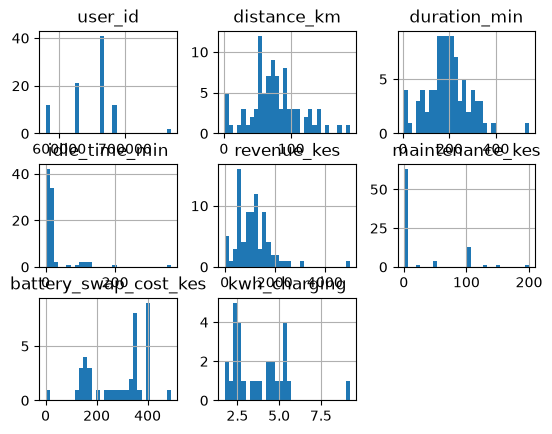

In [173]:
import matplotlib.pyplot as plt
import seaborn as sns

plt.figure(figsize=(12, 8))
transition_ev_daily.hist(bins=30)
plt.title("Distribution of Daily Electric Motorcycle Data")

plt.xticks(rotation=45)
plt.show()

In [185]:
num_cols = transition_ev_daily.select_dtypes(include=['number']).columns
transition_ev_daily[num_cols] = transition_ev_daily[num_cols].fillna(
    transition_ev_daily[num_cols].median()
)

In [186]:
transition_ev_daily.isnull().sum()

user_id                  0
date                     0
distance_km              0
duration_min             0
idle_time_min            0
revenue_kes              0
maintenance_kes          0
battery_swap_cost_kes    0
kwh_charging             0
dtype: int64

In [197]:
transition_ev_daily.insert(0, 'category', 'electric_motorcycle')


In [187]:
transition_ev_trip = pd.read_sql("""SELECT * FROM transition_treatment_electric_motorcycle_trip_data""", conn)

In [188]:
transition_ev_trip.head()

,user_id,start_date,start_time,end_date,end_time,duration_min,distance_km,idle_time_min,start_lat,start_lon,end_lat,end_lon,avg_speed_kmh,avg_moving_speed_kmh,max_speed_kmh
0,579236,2023-12-10,11:06:51,2023-12-10,11:31:01,24.17,15.57,0.35,NaN,NaN,-1.257490,36.803090,38.65,39.22,59.0
1,579236,2023-12-10,12:11:25,2023-12-10,12:16:54,5.48,2.21,0.10,-1.257490,36.803090,-1.258252,36.818900,24.20,24.65,44.0
2,579236,2023-12-10,12:45:26,2023-12-10,12:50:34,5.13,2.52,0.47,-1.258252,36.818900,-1.264077,36.804105,29.47,32.45,53.0
3,579236,2023-12-10,12:53:10,2023-12-10,13:02:45,9.58,4.87,0.73,-1.264077,36.804105,-1.287638,36.777732,30.50,33.02,53.0
4,579236,2023-12-10,13:03:31,2023-12-10,13:05:09,1.63,0.37,0.33,-1.287638,36.777732,-1.288698,36.774793,13.62,17.08,21.0


In [189]:
transition_ev_trip.info()

<class 'pandas.DataFrame'>
RangeIndex: 3655 entries, 0 to 3654
Data columns (total 15 columns):
 #   Column                Non-Null Count  Dtype  
---  ------                --------------  -----  
 0   user_id               3655 non-null   int64  
 1   start_date            3655 non-null   str    
 2   start_time            3655 non-null   str    
 3   end_date              3655 non-null   str    
 4   end_time              3655 non-null   str    
 5   duration_min          3655 non-null   float64
 6   distance_km           3655 non-null   float64
 7   idle_time_min         3655 non-null   float64
 8   start_lat             3567 non-null   float64
 9   start_lon             3567 non-null   float64
 10  end_lat               3567 non-null   float64
 11  end_lon               3567 non-null   float64
 12  avg_speed_kmh         3655 non-null   float64
 13  avg_moving_speed_kmh  3655 non-null   float64
 14  max_speed_kmh         3655 non-null   float64
dtypes: float64(10), int64(1), str(4)

In [190]:
transition_ev_trip.isnull().sum()

user_id                  0
start_date               0
start_time               0
end_date                 0
end_time                 0
duration_min             0
distance_km              0
idle_time_min            0
start_lat               88
start_lon               88
end_lat                 88
end_lon                 88
avg_speed_kmh            0
avg_moving_speed_kmh     0
max_speed_kmh            0
dtype: int64

<Figure size 1200x800 with 0 Axes>

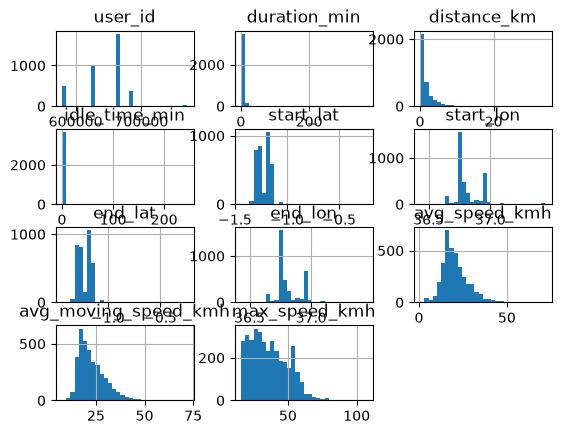

In [191]:
plt.figure(figsize=(12, 8))
transition_ev_trip.hist(bins=30)
plt.title("Distribution of Trip Electric Motorcycle Data")
plt.show()

In [192]:
transition_ev_trip.dropna(inplace=True)

In [193]:
transition_ev_trip.isnull().sum()

user_id                 0
start_date              0
start_time              0
end_date                0
end_time                0
duration_min            0
distance_km             0
idle_time_min           0
start_lat               0
start_lon               0
end_lat                 0
end_lon                 0
avg_speed_kmh           0
avg_moving_speed_kmh    0
max_speed_kmh           0
dtype: int64

In [198]:
transition_ev_trip.insert(0, 'category', 'electric_motorcycle')

In [194]:
transition_fuel_daily_columns = transition_fuel_daily.columns.tolist()

transition_fuel_trip_columns = transition_fuel_trip.columns.tolist()

transition_ev_daily_columns = transition_ev_daily.columns.tolist()

transition_ev_trip_columns = transition_ev_trip.columns.tolist()


print("Transition Fuel Daily Columns:", transition_fuel_daily_columns)
print("Transition Fuel Trip Columns:", transition_fuel_trip_columns)
print("Transition EV Daily Columns:", transition_ev_daily_columns)
print("Transition EV Trip Columns:", transition_ev_trip_columns)


Transition Fuel Daily Columns: ['user_id', 'date', 'distance_km', 'duration_min', 'idle_time_min', 'revenue_kes', 'maintenance_kes', 'fuel_cost_kes', 'fuel_unit_cost_kes_per_l', 'fuel_amount_l']
Transition Fuel Trip Columns: ['user_id', 'start_date', 'start_time', 'end_date', 'end_time', 'duration_min', 'distance_km', 'idle_time_min', 'start_lat', 'start_lon', 'end_lat', 'end_lon', 'avg_speed_kmh', 'avg_moving_speed_kmh', 'max_speed_kmh']
Transition EV Daily Columns: ['user_id', 'date', 'distance_km', 'duration_min', 'idle_time_min', 'revenue_kes', 'maintenance_kes', 'battery_swap_cost_kes', 'kwh_charging']
Transition EV Trip Columns: ['user_id', 'start_date', 'start_time', 'end_date', 'end_time', 'duration_min', 'distance_km', 'idle_time_min', 'start_lat', 'start_lon', 'end_lat', 'end_lon', 'avg_speed_kmh', 'avg_moving_speed_kmh', 'max_speed_kmh']


In [199]:
import pandas as pd

# Tag each dataset
transition_fuel_daily['vehicle_type'] = 'fuel'
transition_ev_daily['vehicle_type']   = 'ev'

transition_daily = pd.concat(
    [transition_fuel_daily, transition_ev_daily],
    axis=0,
    ignore_index=True,
    sort=False            # keeps all columns; missing ones become NaN
)

print(transition_daily.shape)
print(transition_daily['vehicle_type'].value_counts())

(1029, 14)
vehicle_type
fuel    941
ev       88
Name: count, dtype: int64


In [200]:
transition_fuel_trip['vehicle_type'] = 'fuel'
transition_ev_trip['vehicle_type']   = 'ev'

transition_trip = pd.concat(
    [transition_fuel_trip, transition_ev_trip],
    axis=0,
    ignore_index=True
)

print(transition_trip.shape)
print(transition_trip['vehicle_type'].value_counts())

(55280, 17)
vehicle_type
fuel    51799
ev       3481
Name: count, dtype: int64


In [201]:
import sqlite3

conn = sqlite3.connect("emobility_cleaned.db")   

transition_daily.to_sql(
    "transition_daily",   # table name
    conn,
    if_exists="append",   # 'append' | 'replace' | 'fail'
    index=False           # don't write pandas index as a column
)

transition_trip.to_sql(
    "transition_trip",
    conn,
    if_exists="append",
    index=False
)

conn.close()

In [202]:
conn = sqlite3.connect("emobility_cleaned.db")

tables = pd.read_sql_query("SELECT name FROM sqlite_master WHERE type='table';", conn)
print(tables)

                        name
0                battery_eol
1        country_qualitative
2              eac_countries
3             fiscal_tariffs
4     industrial_value_chain
5               market_fleet
6           policy_inventory
7              power_systems
8   eac_ev_charging_stations
9           transition_daily
10           transition_trip
